# **Shorのアルゴリズムで $n=15$ を因数分解する — RSAを破る仕組みを体験するハンズオン**

**著者**: 甘利 丈慈 (Jorge Amari)　**バージョン**: v1.0.0 (2026-04)　**ライセンス**: CC-BY-NC-ND-4.0（文章・図表）/ MIT（コード）


## **0. はじめに**


### **0.1 このハンズオンでやること**



**「量子コンピュータでRSA暗号が破れる」と言われるが、具体的にどうやって破るのか？ 現状どれくらい現実的な脅威なのか？**

RSA暗号の安全性は、大きな数の素因数分解が古典計算では現実的な時間で解けないことに依存している (→ 本書 第2章) 。もし素因数分解を効率的に解くアルゴリズムがあれば、RSA暗号は破られる。Shorのアルゴリズムはまさにそのアルゴリズムである。

本ハンズオンでは、その仕組みであるShorのアルゴリズムを $n = 15$ の因数分解 ($15 = 3 \times 5$) を題材に、実際にコードを動かしながら体験する。

具体的には以下を行う

1. **位数と因数分解の関係を体験する** (古典計算) \
$a^r \equiv 1 \pmod{n}$ を満たす $r$ (位数) が分かれば、$\gcd$ だけで素因数が求まることを確認する
2. **古典計算の限界を体感する**\
古典計算では、位数を求める計算時間が $n$ の増大とともに急増し、RSA-2048 には到底届かないことを実感する
3. **量子回路を1ステップずつ構成する**\
Shorのアルゴリズムの量子回路を、加算器の構築から始めて段階的に組み上げ、シミュレータで実行する
4. **測定結果から因数分解を完了する**\
回路の出力から連分数展開で位数を復元し、$15 = 3 \times 5$ を導く
5. **理想と現実のギャップを確認する**\
回路規模から見た現状のデバイスとの距離感を把握し、ノイズありのシミュレーションで結果がどう崩れるかを観察する

上の1–4が Shorのアルゴリズムの本体であり、5は現状の量子コンピュータとのギャップの確認である。

Shorのアルゴリズムは、量子コンピュータによる計算の基本的な枠組みに従っており、

- **初期状態の準備**\
量子ビットを所定の状態にセットする
- **量子ゲートの作用**\
ユニタリ演算子を順に作用させ、状態を変換する
- **測定＋古典計算**\
量子ビットを測定し、その結果をもとに古典計算で欲しい答えを求める

素因数分解を「位数発見」という問題に帰着させ、量子回路で位数を求めた後、古典計算で因数分解を完了する。本ハンズオンでは、この流れを1ステップずつ体験していく。

### **0.2 本ノートの構成**






まず古典の話として、位数と素因数分解の関係を確認し、素朴な古典計算ではその位数を求めるのに指数時間がかかる（古典最良既知法でも準指数時間）ことを体感する。次に、Shor のアルゴリズムの量子回路を加算器の構築から段階的に組み上げ、シミュレータで実行して因数分解を完了する。ここが本ハンズオンの中心である。最後に、現状の量子コンピュータで RSA を破れるのかを考える。回路規模から見た現状とのギャップを確認し、ノイズありのシミュレーションで結果がどう崩れるかを観察する。


| パート | 内容 | 本書の対応 |
|-------|------|----------|
| 1章 : 位数発見問題 | 位数の定義、位数→素因数分解、古典計算の限界 | → 本書「位数発見問題」節 |
| 2章 : Shorのアルゴリズムを動かす | 加算器から段階的に回路を組み上げ、シミュレータで実行し因数分解を完了 | → 本書「Shorのアルゴリズムの手順」節, 「実装方法」節 |
| 3章 : 理想と現実のギャップ | 回路規模から見た現状とのギャップ、ノイズの影響 | → 本書「実用性の分析」節 |
| おわりに | 本ハンズオンのまとめ | |


### **0.3 ハンズオンを実施する前提と理論パート (本書 第3章)の使い方**




- **理論パートを読まなくても実行はできる**\
本ノートブックは各ステップで理論の要点を説明しながら進めるため、理論パート (本書 第3章) を読んでいなくても実行できるように設計されている。ただし、後半 (逆QFT・ノイズ分析など) を深く理解するには、線形代数・複素指数関数に抵抗がないことが望ましい
- **理論の詳細は理論パート (本書 第3章)を参照**\
各セルに `→ 本書 X.Y節` のリンクを記載している。ハンズオンを進める中で「なぜこうなるのか」「数学的な背景をもっと知りたい」と思ったら、随時理論パート (本書 第3章)の該当節を読むことを推奨する。本ノートブックで体験し、理論パート (本書 第3章)で理論を補強する、という使い方が最も効果的である

### **0.4 この教材の設計方針**



- **あくまでシミュレータを使用**\
汎用版のShorアルゴリズムは $n=15$ でも18量子ビット・数千ゲートが必要であり、現状のNISQデバイスでは回路が深すぎて正しい結果が得られない (→ 本書「現状の技術での課題」節) 。そのため、シミュレータ上で任意の $n$ に対応するBeauregard (2003) のフーリエ空間算術をベースにした汎用回路を構築し、シミュレータで動かす
- **トイプログラムではない**\
一方で、量子コンピュータで$n=15$ を因数分解したというニュースを見たことがあるかもしれない。しかしそれらの多くは、特定の $(a, n)$ に対して「正しい結果を生む最小回路」を逆算して設計した専用回路 (コンパイル版) である。\
$n=15$ 用の回路で $n=21$ は解けず、因数分解問題を汎用的に解いたとは言えない (→ 本書「現状の技術での課題」節 コラム) 。本ハンズオンでは、**小さな奇数合成数 $n$ と $\gcd(a, n)=1$ を満たす $a$ に対して動作する汎用構成の回路** (Beauregard 2003 のフーリエ空間算術ベース) を使用する

### **0.5 記法の整理 (→ 本書「はじめに」節)**



| 記号 | 意味 |
|------|------|
| $\lvert 0\rangle$, $\lvert 1\rangle$ | 量子ビットの計算基底状態 |
| $\alpha\lvert 0\rangle + \beta\lvert 1\rangle$ | 重ね合わせ状態（$\lvert\alpha\rvert^2 + \lvert\beta\rvert^2 = 1$） |
| $\otimes$ | テンソル積 |
| $U$ | 量子ゲート（ユニタリ演算子） |
| $e^{2\pi i \varphi}$ | ユニタリ演算子の固有値。$\varphi$ を「位相」と呼ぶ |
| $P(z) = \lvert\langle z\lvert\psi\rangle\rvert^2$ | ボルンの規則（測定確率） |


### **0.6 事前準備**



以下のセルで、本ハンズオンに必要なライブラリ (Qiskit、NumPy等) を読み込む。

> **やること**\
● 必要なライブラリを読み込み、実行環境を整える  
>ここが通れば、以降の全セルが実行可能になる

In [1]:
!pip install -q qiskit==2.3.1 qiskit-aer==0.17.2 japanize-matplotlib==1.1.3 pylatexenc==2.10

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 19.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00


In [2]:
# === 環境準備 ===
import numpy as np
from math import gcd, ceil, log2
from fractions import Fraction
import matplotlib.pyplot as plt
import matplotlib

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT, PhaseGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# --- 日本語フォント設定 ---
import sys, subprocess
try:
    import japanize_matplotlib
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'japanize-matplotlib'], check=True)
    import japanize_matplotlib

# 再現性のためのシード固定
SEED = 42
np.random.seed(SEED)

print("環境準備完了")

環境準備完了


---

## 1. **位数発見問題 (Order Finding Problem)**

→ 本書 第3章 3.2節「位数発見問題」

Shorのアルゴリズムは「素因数分解」を直接解くのではなく、「**位数発見**」という別の問題に帰着させる。
本章では、「位数が分かれば素因数が高確率で求められる」ことを、コードで確認する。

### **1.1 位数の定義 (→ 本書「位数の定義」節)**

$a$ と $n$ を互いに素な自然数 ($\gcd(a, n) = 1$) とする。

$$a^r \equiv 1 \pmod{n} \tag{1.1}$$

を満たす最小の正の整数 $r$ を、$a$ の $\bmod\ n$ における「**位数** (order)」と呼ぶ。



#### 具体例: $n = 15$, $a = 7$ の場合 (→ 本書「位数の定義」節の具体例)



- $7^1 \bmod 15 = 7$
- $7^2 \bmod 15 = 49 \bmod 15 = 4$
- $7^3 \bmod 15 = 7 \cdot 4 = 28 \bmod 15 = 13$
- $7^4 \bmod 15 = 7 \cdot 13 = 91 \bmod 15 = 1$ ✓

したがって $\text{ord}_{15}(7) = 4$ である。

上記を以下のコードで確認する。

> **やること**\
● 合成数 $n=15$ に対して、$a=7$ と $a=11$ について、$a^k \bmod 15$ を $1$ 乗から順に計算し、$1$ に戻った時点の指数を確認する (= 位数)  
> **ポイント**\
● $n=15$ に対して、位数は $a$ の値によっても異なる。

In [3]:
# --- 本書の具体例を再現: 累乗を順に計算して位数を確認 ---
n = 15

# 具体例 1: n=15, a=7
a = 7
print(f"=== 具体例 1: n={n}, a={a} ===")
for k in range(1, 6):
    val = pow(a, k, n)  # a^k mod n を計算
    marker = " ← 位数 r=" + str(k) if val == 1 else ""
    print(f"  {a}^{k} mod {n} = {val}{marker}")

print()

# 具体例 2: n=15, a=11
a = 11
print(f"=== 具体例 2: n={n}, a={a} ===")
for k in range(1, 4):
    val = pow(a, k, n)
    marker = " ← 位数 r=" + str(k) if val == 1 else ""
    print(f"  {a}^{k} mod {n} = {val}{marker}")

print()
print("ポイント: 同じ n=15 に対して a=7 なら位数 4、a=11 なら位数 2。")
print("位数は a によって異なる。")

=== 具体例 1: n=15, a=7 ===
  7^1 mod 15 = 7
  7^2 mod 15 = 4
  7^3 mod 15 = 13
  7^4 mod 15 = 1 ← 位数 r=4
  7^5 mod 15 = 7

=== 具体例 2: n=15, a=11 ===
  11^1 mod 15 = 11
  11^2 mod 15 = 1 ← 位数 r=2
  11^3 mod 15 = 11

ポイント: 同じ n=15 に対して a=7 なら位数 4、a=11 なら位数 2。
位数は a によって異なる。


この計算を以降のセルでも繰り返し使うので、関数にまとめておく。

> **やること**\
● $a, n$ から、位数を計算する関数 `compute_order(a, n)` を定義する。\
● $a = 7, n = 15$ の時と、$a = 11, n = 15$ の時で関数を実行し、正しい位数が得られていることを確認する。

In [4]:
def compute_order(a: int, n: int) -> int:
    """位数 r を計算する: a^r ≡ 1 (mod n) を満たす最小の正整数 r"""
    if gcd(a, n) != 1:
        raise ValueError(f"gcd({a}, {n}) = {gcd(a, n)} != 1: a と n は互いに素でない")
    # 上のforループと同じ方法: a^r mod n を r=1,2,3,... と順に試す
    r = 1
    while pow(a, r, n) != 1:
        r += 1
    return r


# --- 動作確認: 上のforループと同じ結果が得られることを確認 ---
n = 15
print(f"compute_order(7, {n}) = {compute_order(7, n)}")   # → 4
print(f"compute_order(11, {n}) = {compute_order(11, n)}")  # → 2

compute_order(7, 15) = 4
compute_order(11, 15) = 2


ここまでで、$a=7$ と $a=11$ の位数を具体的に求めた。同じ $n=15$ でも $a$ によって位数が異なることが分かった。

この後の1.2節では「位数から素因数分解ができる」ことを示すが、実は全ての $a$ でうまくいくわけではない。$a$ の選び方によって位数は変わり、因数分解に使えるかどうかも変わってくる。

そこで先に、$n=15$ に対する全ての $a$ の位数を列挙しておく。後で1.2節の条件と照合して「どの $a$ なら成功し、どの $a$ なら失敗するか」を確認する材料にする。

> **やること**\
● $n=15$ の全ての $a$ について位数を計算する\
● $a$ によって位数が異なることを一覧で確認する  

In [5]:
# --- n=15 に対する全ての a の位数を計算 (aによって値も循環も変化する) ---
n = 15
print(f"=== n={n} に対する各 a の位数 ===")
print(f"{'a':>3s}  {'gcd(a,n)':>8s}  {'位数 r':>6s}  {'a の累乗 mod n の巡回列'}")
print("-" * 65)

coprime_a_list = []  # 互いに素な a と位数を記録 (1.2節で使う)

for a in range(2, n):
    g = gcd(a, n)
    if g != 1:
        print(f"{a:>3d}  {g:>8d}  {'---':>6s}  (互いに素でない → gcd が因数)")
    else:
        r = compute_order(a, n)
        # 巡回列を表示
        cycle = [pow(a, k, n) for k in range(1, r + 1)]
        coprime_a_list.append((a, r))  # 互いに素な a と位数を記録 (1.2節で使う)
        print(f"{a:>3d}  {g:>8d}  {r:>6d}  {cycle}")

=== n=15 に対する各 a の位数 ===
  a  gcd(a,n)    位数 r  a の累乗 mod n の巡回列
-----------------------------------------------------------------
  2         1       4  [2, 4, 8, 1]
  3         3     ---  (互いに素でない → gcd が因数)
  4         1       2  [4, 1]
  5         5     ---  (互いに素でない → gcd が因数)
  6         3     ---  (互いに素でない → gcd が因数)
  7         1       4  [7, 4, 13, 1]
  8         1       4  [8, 4, 2, 1]
  9         3     ---  (互いに素でない → gcd が因数)
 10         5     ---  (互いに素でない → gcd が因数)
 11         1       2  [11, 1]
 12         3     ---  (互いに素でない → gcd が因数)
 13         1       4  [13, 4, 7, 1]
 14         1       2  [14, 1]


$a$ と $n$ が互いに素でない場合 ($\gcd(a, n) \neq 1$) は、位数を求めるまでもなく $\gcd(a, n)$ がそのまま $n$ の因数になる。例えば $\gcd(6, 15) = 3$ なら $15 = 3 \times 5$ と即座に分かる。\
(もちろん、$a, n$ が大きな数ではこのラッキーなケースはほとんど起きないが)

一方で、上のセルで記録した `coprime_a_list` (互いに素な $a$ とその位数のリスト) は、この後の全数サーベイで「どの $a$ なら因数分解が成功するか」を確認する際に使う。

### **1.2 位数から素因数分解へ (→ 本書「位数から素因数分解へ」節)**


位数 $r$ が求まれば、以下の手順で素因数 $p, q$ を求めることができる。ただし、**2つの条件**を満たす必要があり、満たさない場合は別の $a$ でやり直す。


#### ⭐**位数 $r$ から素因数分解をする手順の全体像**

![位数rからの素因数分解フロー](factorization_flow.png)

#### **条件①: $r$ が偶数であること**



$a^r \equiv 1 \pmod{n}$ より $a^r - 1 = kn$ ($k$ は整数) 。$r$ が偶数なら:

$$(a^{r/2} + 1)(a^{r/2} - 1) = kn \tag{1.3}$$

と因数分解できる。$r$ が奇数だとこの分解ができないため失敗とみなす。



#### **条件②: $a^{r/2} \not\equiv -1 \pmod{n}$ であること**



式(1.3) の2つの因数について考える。

- $(a^{r/2} - 1)$ は $n$ の倍数ではない。\
もし $a^{r/2} \equiv 1 \pmod{n}$ だとすると $\frac{r}{2}$ が位数の定義を満たすことになり、$r$ が最小という位数の定義に矛盾する。
- 一方、$(a^{r/2} + 1)$ が $n$ の倍数かどうかは $a$ の値に依存する。\
もし $a^{r/2} \equiv -1 \pmod{n}$ だと $(a^{r/2} + 1) \equiv 0 \pmod{n}$ となり、$\gcd(a^{r/2}+1, n) = n$ で自明な値しか得られず失敗する。

#### **両方の条件を満たす場合**



条件①②を両方満たせば、$(a^{r/2}+1)$ も $(a^{r/2}-1)$ も $n$ の倍数ではない。しかし、その積は $kn$ ($n$ の倍数) である。したがって $n = p \times q$ の因数 $p, q$ が $(a^{r/2}+1)$ と $(a^{r/2}-1)$ に分配されており、以下の通り、$\gcd$ で取り出せる。

$$p = \gcd(a^{r/2} + 1, n), \quad q = \gcd(a^{r/2} - 1, n) \tag{1.4}$$

#### **位数から因数分解までの流れを実装**

それでは、コード上で、位数から素因数分解までの流れを確認していく\
まず $n=15, a=7$ の具体例で試す。1.1節で求めた通り $a=7$ の位数は $r=4$ (偶数) であり、条件①を満たす。さらに、$a=7$ は条件②も満たすため因数分解に成功する。\
——ただし、これは $a=7$ がたまたま両方の条件を満たすからであり、全ての $a$ で成功するわけではない。この後すべての $a$ を列挙し、どの程度成功するのかを確認してみる。

> **やること**\
● 位数 $r=4$ から $\gcd$ の計算だけで $15 = 3 \times 5$ が得られることを確認する  
> **ポイント**\
● 位数さえ分かれば、あとは古典計算 ($\gcd$) だけで素因数が求まる。量子計算の出番は位数を求める部分だけ  

In [6]:
# --- 具体例: n=15, a=7, r=4 で条件①②を確認し因数分解する ---
n, a = 15, 7
r = compute_order(a, n)
print(f"=== 位数から素因数分解: n={n}, a={a}, r={r} ===")
print()

# 条件① の確認
print(f"条件①: r={r} は偶数か？ → {'Yes' if r % 2 == 0 else 'No (失敗) '}")
print()

# 条件② の確認
x = pow(a, r // 2, n)
print(f"条件②: a^(r/2) = {a}^{r//2} mod {n} = {x}")
print(f"  {x} ≡ -1 (mod {n}) か？ → {'Yes (失敗) ' if x == n-1 else 'No → 条件クリア'}")
print()

# 両条件クリア → 式(1.4) で素因数を計算
print(f"両方の条件を満たすので、式(1.4) で素因数を計算:")
print(f"  p = gcd({x}+1, {n}) = gcd({x+1}, {n}) = {gcd(x+1, n)}")
print(f"  q = gcd({x}-1, {n}) = gcd({x-1}, {n}) = {gcd(x-1, n)}")
print()
print(f"結果: {n} = {gcd(x+1, n)} × {gcd(x-1, n)}")
print(f"因数分解成功!")

=== 位数から素因数分解: n=15, a=7, r=4 ===

条件①: r=4 は偶数か？ → Yes

条件②: a^(r/2) = 7^2 mod 15 = 4
  4 ≡ -1 (mod 15) か？ → No → 条件クリア

両方の条件を満たすので、式(1.4) で素因数を計算:
  p = gcd(4+1, 15) = gcd(5, 15) = 5
  q = gcd(4-1, 15) = gcd(3, 15) = 3

結果: 15 = 5 × 3
因数分解成功!


#### **位数から因数分解までの流れを関数化**

上のセルで体験した「条件① ($r$ が偶数か) → 条件② ($a^{r/2} \equiv -1$ でないか) → 式(1.4) で $\gcd$ から素因数を求める」という一連の手順を、以降のセルでも再利用するため関数 `factorize_from_order(a, n, r)` にまとめる。

> **やること**\
● 位数がわかっている前提で、条件①②のチェックと因数分解を `factorize_from_order(a, n, r)` として関数化する。\
● $a=7$ での動作確認。

| 条件 | `status` | `factors` | 意味 |
|------|----------|-----------|------|
| 条件① 不成立 ($r$ が奇数)  | `'r_odd'` | `None` | 式(1.3)の因数分解ができない |
| 条件② 不成立 ($a^{r/2} \equiv -1$)  | `'ar2_eq_minus1'` | `None` | $\gcd$ が自明な値しか返さない |
| 両方成立 → 因数分解成功 | `'success'` | `(p, q)` | $n = p \times q$ |

In [7]:
def factorize_from_order(a: int, n: int, r: int) -> dict:
    """位数 r から素因数分解を試みる (本書「位数発見問題」節)

    Returns:
        dict: status ('success', 'r_odd', 'ar2_eq_minus1', 'gcd_trivial') と factors
    """
    # --- 条件①: r が偶数か？ ---
    if r % 2 != 0:
        return {'status': 'r_odd', 'factors': None,
                'detail': f'条件① 不成立: r={r} は奇数 → 式(1.3)の因数分解ができない'}

    # --- 条件②: a^(r/2) ≡ -1 (mod n) でないか？ ---
    x = pow(a, r // 2, n)
    if x == n - 1:  # a^(r/2) ≡ -1 (mod n)
        return {'status': 'ar2_eq_minus1', 'factors': None,
                'detail': f'条件② 不成立: a^(r/2) = {a}^{r//2} mod {n} = {x} ≡ -1 → gcd が自明'}

    # --- 両方の条件を満たす → 式(1.4) で素因数を計算 ---
    p = gcd(x + 1, n)
    q = gcd(x - 1, n)

    # gcd が自明な値 (1 または n) しか返さない場合
    if p in (1, n) or q in (1, n):
        return {'status': 'gcd_trivial', 'factors': None,
                'detail': f'gcd({x}+1, {n})={p}, gcd({x}-1, {n})={q} → 自明な因数のみ'}

    return {'status': 'success', 'factors': (p, q),
            'detail': f'gcd({x}+1, {n})={p}, gcd({x}-1, {n})={q}'}


# --- 動作確認: 上の具体例と同じ結果が得られることを確認 ---
n, a = 15, 7
r = compute_order(a, n)
result = factorize_from_order(a, n, r)
print(f"factorize_from_order({a}, {n}, {r}) → status={result['status']}, factors={result['factors']}")
print(f"  {result['detail']}")

factorize_from_order(7, 15, 4) → status=success, factors=(5, 3)
  gcd(4+1, 15)=5, gcd(4-1, 15)=3


#### **Q. 適当に選んだ $a$ で成功するものなのか**

Shorのアルゴリズムでは $a$ をランダムに選ぶ。もし成功する $a$ の割合が低ければ、何度もやり直す必要があり実用的でなくなる。そこで、1.1節で記録した `coprime_a_list` ($n=15$ と互いに素な $a$ とその位数のリスト) の全ての $a$ に対して因数分解を試み、どの $a$ が成功し、どの $a$ が失敗するか、成功率はどのくらいかを確認する。

> **注意**\
このコードは理論の証明ではなく、$n=15$ という小さい具体例で結果を眺める確認コードである。「成功する $a$ の割合が $1/2$ 以上」であることは数学的に証明された定理 (→ 本書「成功確率と全体の計算量」節 コラム) であり、ここでは $n=15$ の場合にその定理と整合する結果が得られることを確認する。

> **やること**\
● 1.1節で記録した各 $a$ について、位数 $r$ → 条件① ($r$ が偶数か) → 条件② ($a^{r/2} \equiv -1$ でないか) → $\gcd$ で因数分解、という手順を `factorize_from_order` で実行し、成功/失敗のパターンを観察する  
> **ポイント**\
● 少なくとも $n=15$ の具体例では、$\frac{6}{7}$ の確率で成功することを確認する (厳密には $\frac{1}{2}$ 以上の確率で成功することが知られている→ 本書「成功確率と全体の計算量」節 コラム)

In [8]:
# --- 1.1節で記録した互いに素な a について因数分解を試みる ---
n = 15
print(f"=== n={n}: 互いに素な a について位数→因数分解を試みる ===")
print(f"{'a':>3s}  {'r':>3s}  {'r偶数':>5s}  {'a^(r/2) mod n':>14s}  {'状態':>20s}  {'因数':>10s}")
print("-" * 70)

success_count = 0
for a, r in coprime_a_list:
    # factorize_from_order は内部で条件①②を計算しているが、結果(status)しか返さない
    # 表に条件の値を表示するため、同じ計算を手前でも行っている
    r_even = 'Yes' if r % 2 == 0 else 'No'
    ar2 = str(pow(a, r // 2, n)) if r % 2 == 0 else '---'

    # factorize_from_order で条件①②のチェック → 因数分解を実行
    result = factorize_from_order(a, n, r)
    factors_str = f"{result['factors'][0]}×{result['factors'][1]}" if result['factors'] else '---'
    if result['status'] == 'success':
        success_count += 1
    print(f"{a:>3d}  {r:>3d}  {r_even:>5s}  {ar2:>14s}  {result['status']:>20s}  {factors_str:>10s}")

total = len(coprime_a_list)
print()
print(f"成功: {success_count}/{total} = {success_count/total:.0%}")
print(f"→ 成功率 ≥ 1/2 の定理と整合している")

=== n=15: 互いに素な a について位数→因数分解を試みる ===
  a    r    r偶数   a^(r/2) mod n                    状態          因数
----------------------------------------------------------------------
  2    4    Yes               4               success         5×3
  4    2    Yes               4               success         5×3
  7    4    Yes               4               success         5×3
  8    4    Yes               4               success         5×3
 11    2    Yes              11               success         3×5
 13    4    Yes               4               success         5×3
 14    2    Yes              14         ar2_eq_minus1         ---

成功: 6/7 = 86%
→ 成功率 ≥ 1/2 の定理と整合している


### **1.3 本章のまとめ**


1章では、Shorのアルゴリズムが素因数分解を「位数発見」という問題に帰着させていることを、$n=15$ の具体例で体験した。

- **位数が分かれば因数分解できる**\
位数 $r$ が条件①②を満たせば、$\gcd$ だけで素因数が求まる。$a=7, r=4$ で $15 = 3 \times 5$ を導いた (1.2節)
- **成功率は十分高い**\
$n=15$ の全数サーベイで成功率 $86\%$ を観察した。一般の $n$ でも $\geq 1/2$ が数学的に保証されている (→ 本書「成功確率と全体の計算量」節)

→ **因数分解実現の問題は位数をどうやって求めるかに帰着する**

(※ ここまでの計算は全て古典計算であり、量子コンピュータは全く関係のない話である。)

## ⭐ **古典的な位数計算の限界 — なぜ量子コンピュータが必要か？**



#### **総当たり位数探索のおもちゃデモ**

RSA暗号の安全性は「大きな数の素因数分解が古典計算では現実的な時間で解けない」ことに依存している。もし位数の発見が高速にできれば、1章で示した方法で素因数分解が可能になり、RSA暗号は破られる。

$n=15$ では `compute_order` は一瞬で終わった。では $n$ が大きくなったらどうか？ 実際に $n$ のビット数を増やしながら `compute_order` を実行し、計算時間がどう変わるかを測ってみる。

ただし注意として、`compute_order` は $a^k \bmod n$ を $k = 1, 2, \ldots$ と順に試す素朴な総当たり法であり、位数 $r$ に対して $O(r)$ 回のべき乗計算を行う。$r$ は最悪で $n$ 程度になるため、計算量は $n$ に対して指数的 ($O(2^L)$, $L$ は $n$ のビット数) である。以下の結果は「Shor が量子的に高速化する対象を、古典で素朴にやるとすぐに苦しくなる」ことのデモである。選んだ $a$ の位数によって個々の計算時間が大きく変わるため、グラフはギザギザになる点にも注意されたい。

> **やること**\
● 総当たり法 (`compute_order`) の計算時間を、$n$ のビット数を約 8〜27 ビットまで増やして計測する\
→ ビット数 vs 計算時間の対数グラフを出力する

=== 総当たり位数探索 (compute_order) ===
  n bits                 n        位数 r        time
--------------------------------------------------
       8               143          60     0.0000s
       9               493          56     0.0000s
      11              1961         468     0.0055s
      13              6499         528     0.0005s
      15             25283        6240     0.0281s
      17             99973        1552     0.0060s
      19            400649       24960     0.1297s
      21           1590833      397065     1.5580s
      23           6321187        6156     0.0161s
      25          25212949     4200450    14.2971s
      27         100880401     1050624     1.7024s


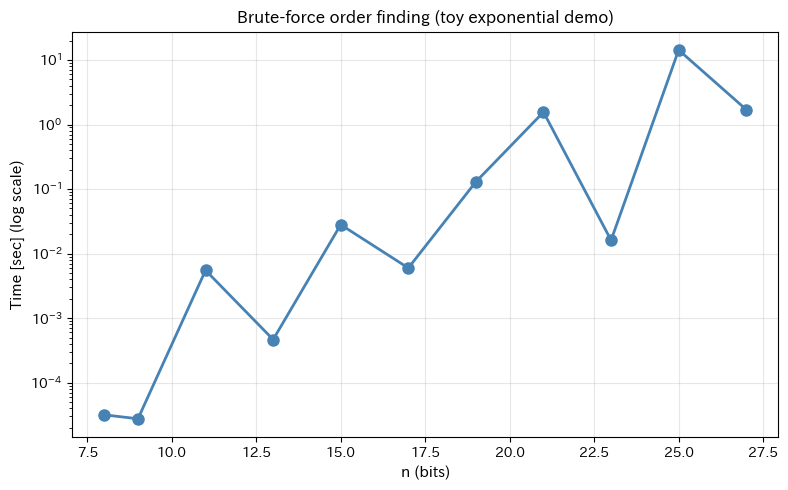


27ビット程度で既に数秒かかる。RSA-2048 (2048ビット) には到底届かない。
では、実用的な古典アルゴリズムならどうか？ → 次のセルで篩法の発想を見る。


In [9]:
# === 総当たり位数探索の計算時間 (toy exponential demo) ===
# Shor が高速化する対象である「位数探索」を、古典で素朴にやるとどうなるかを見る。
# 選んだ a の位数に依存するため個体差が大きい (グラフはギザギザになる) 。

import time
from sympy import nextprime

print("=== 総当たり位数探索 (compute_order) ===")
print(f"{'n bits':>8s}  {'n':>16s}  {'位数 r':>10s}  {'time':>10s}")
print("-" * 50)

bit_sizes_brute = []
times_brute = []

for p_bits in range(3, 14):
    p = nextprime(2**p_bits)
    q = nextprime(2**p_bits + 2**p_bits // 2)
    n = p * q
    a = 2
    while gcd(a, n) != 1:
        a += 1

    t1 = time.perf_counter()
    r = compute_order(a, n)
    elapsed = time.perf_counter() - t1

    bit_sizes_brute.append(n.bit_length())
    times_brute.append(elapsed)
    print(f"{n.bit_length():>8d}  {n:>16d}  {r:>10d}  {elapsed:>9.4f}s")

# --- グラフを描画 ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(bit_sizes_brute, times_brute, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('n (bits)', fontsize=11)
ax.set_ylabel('Time [sec] (log scale)', fontsize=11)
ax.set_title('Brute-force order finding (toy exponential demo)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("27ビット程度で既に数秒かかる。RSA-2048 (2048ビット) には到底届かない。")
print("では、実用的な古典アルゴリズムならどうか？ → 次のセルで篩法の発想を見る。")

#### **篩法の発想 — 古典の実用的な因数分解はどう動くか**

`compute_order` の総当たりは指数時間であり、当然ながら実用的な古典因数分解はこのような方法を使わない。実際に使われるのは**篩法 (sieve method)** と呼ばれる一群のアルゴリズムである (二次篩法、数体篩法など)。その計算量は準指数時間 (指数と多項式の中間) であり、理論的にも総当たりより根本的に速い (→ 本書「古典アルゴリズムとの比較」節)。

篩法の核心は、**平方合同** $X^2 \equiv Y^2 \pmod{N}$ を見つけることにある。これが見つかれば $\gcd(X - Y,\, N)$ で非自明な因数が得られる (1章の位数からの因数分解と同じ構造である)。篩法では、$Q(x) = (A + x)^2 - N$ ($A = \lfloor\sqrt{N}\rfloor$) を多数計算し、**小さい素数だけで割り切れるもの (B-smooth)** を集める。十分な本数の smooth relation が集まると、指数の偶奇に線形従属が生まれ、積が完全平方になる組み合わせを作れる。

以下では $N = 1649$ を具体例に、この流れを1セルで体験する。

In [10]:
# === 篩法の発想: B-smooth な値を集めて平方合同を作る ===
import math

N_sieve = 1649  # 因数は見ない前提で進める
A_sieve = math.isqrt(N_sieve)
factor_base = [-1, 2, 5, 7]  # 因子基底 (教育用に smooth relation が少数見つかる小さな基底を手で選んでいる)

print(f"N = {N_sieve},  A = floor(sqrt(N)) = {A_sieve}")
print(f"因子基底 F = {factor_base}")
print(f"Q(x) = (A + x)² − N を計算し、F の元だけで割り切れるもの (B-smooth) を探す")
print()

# --- Q(x) を計算し B-smooth 判定 ---
print(f"{'x':>3s}  {'A+x':>5s}  {'Q(x)':>8s}  {'因数分解':<20s}  {'smooth?'}")
print("-" * 58)

smooth = []  # (x, A+x, Q(x), exponents_dict)

for x in range(12):
    Ax = A_sieve + x
    Qx = Ax**2 - N_sieve
    if Qx == 0:
        continue

    # Q(x) を因子基底で割ってみる
    remaining = abs(Qx)
    exps = {}
    if Qx < 0:
        exps[-1] = 1
    for p in [2, 5, 7]:
        e = 0
        while remaining % p == 0:
            remaining //= p
            e += 1
        if e > 0:
            exps[p] = e

    is_smooth = (remaining == 1)

    # 因数分解の文字列
    parts = []
    if -1 in exps:
        parts.append('−1')
    for p in [2, 5, 7]:
        if p in exps:
            parts.append(f'{p}^{exps[p]}' if exps[p] > 1 else str(p))
    if not is_smooth:
        parts.append(str(remaining))
    fac_str = ' × '.join(parts) if parts else str(Qx)

    mark = '  ✓' if is_smooth else ''
    print(f"{x:>3d}  {Ax:>5d}  {Qx:>8d}  {fac_str:<20s} {mark}")

    if is_smooth:
        smooth.append((x, Ax, Qx, exps))

# --- Parity matrix ---
print(f"\n=== Smooth relation の指数の偶奇 (parity vector) ===")
print(f"{'':>5s}  {'−1':>3s} {'2':>3s} {'5':>3s} {'7':>3s}   Q(x)")
print("-" * 40)
for x, Ax, Qx, exps in smooth:
    parity = [exps.get(p, 0) % 2 for p in [-1, 2, 5, 7]]
    parity_str = '  '.join(f'{v:>2d}' for v in parity)
    print(f"x={x:<2d}   {parity_str}   {Qx}")

# --- x=1 と x=3 の parity が一致 → 積が完全平方 ---
print(f"\n→ x=1 と x=3 の parity が一致! 積を取ると全ての指数が偶数になる:")
print(f"  Q(1) × Q(3) = {smooth[1][2]} × {smooth[2][2]} = {smooth[1][2] * smooth[2][2]} = {int(math.sqrt(smooth[1][2] * smooth[2][2]))}²")
print()

X = (smooth[1][1] * smooth[2][1]) % N_sieve
Y = int(math.sqrt(smooth[1][2] * smooth[2][2]))
print(f"X = (A+1)(A+3) mod N = {smooth[1][1]}×{smooth[2][1]} mod {N_sieve} = {X}")
print(f"Y = {Y}")
print(f"gcd(X−Y, N) = gcd({X - Y}, {N_sieve}) = {math.gcd(X - Y, N_sieve)}")
print(f"gcd(X+Y, N) = gcd({X + Y}, {N_sieve}) = {math.gcd(X + Y, N_sieve)}")
print()
p_found = math.gcd(X - Y, N_sieve)
q_found = math.gcd(X + Y, N_sieve)
print(f"→ {N_sieve} = {p_found} × {q_found}")

N = 1649,  A = floor(sqrt(N)) = 40
因子基底 F = [-1, 2, 5, 7]
Q(x) = (A + x)² − N を計算し、F の元だけで割り切れるもの (B-smooth) を探す

  x    A+x      Q(x)  因数分解                  smooth?
----------------------------------------------------------
  0     40       -49  −1 × 7^2               ✓
  1     41        32  2^5                    ✓
  2     42       115  5 × 23               
  3     43       200  2^3 × 5^2              ✓
  4     44       287  7 × 41               
  5     45       376  2^3 × 47             
  6     46       467  467                  
  7     47       560  2^4 × 5 × 7            ✓
  8     48       655  5 × 131              
  9     49       752  2^4 × 47             
 10     50       851  851                  
 11     51       952  2^3 × 7 × 17         

=== Smooth relation の指数の偶奇 (parity vector) ===
        −1   2   5   7   Q(x)
----------------------------------------
x=0     1   0   0   0   -49
x=1     0   1   0   0   32
x=3     0   1   0   0   200
x=7     0   0   1   1   560

→ x=

#### **実用的古典法 (SIQS) のベンチマーク**

上のセルで体験した「smooth relation を集めて平方合同を作る」という発想を、大きな $N$ にも適用できるよう自動化・高速化したのが **Self-Initializing Quadratic Sieve (SIQS)** である。二次篩法系は、中規模の整数に対して有効な準指数時間アルゴリズムである。実務では高速な専用実装 (Msieve, CADO-NFS 等) が使われるが、ここでは SymPy の SIQS 実装を教材として用い、60〜110 ビット程度の半素数に対する計算時間を観察する。それより大きい整数には数体篩法 (GNFS) が使われる。いずれにせよ、古典の最良アルゴリズムは準指数時間であり、Shor の多項式時間 $O(L^3)$（$L = \log_2 n$ は入力ビット長）とは根本的に異なる (→ 本書「古典アルゴリズムとの比較」節)。

> **やること**\
● SIQS (`sympy.ntheory.qs.qs`) の計算時間を、$n$ のビット長 約 60〜110 ビットまで計測する\
→ ビット数 vs 計算時間の対数グラフを出力する\
> **ポイント**\
● 総当たり法が 27 ビットで苦しくなったのに対し、SIQS は 100 ビット超まで到達できる。しかし、それでもビット数の増加に対して計算時間は急増し、RSA-2048 (2048ビット) には到底届かない。

=== SIQS (sympy.ntheory.qs.qs) ===
  n bits        time          結果
-----------------------------------
      61       0.40s          成功
      71       0.90s          成功
      81       0.70s          成功
      91       2.28s          成功
     101       4.21s          成功
     111       3.74s          成功


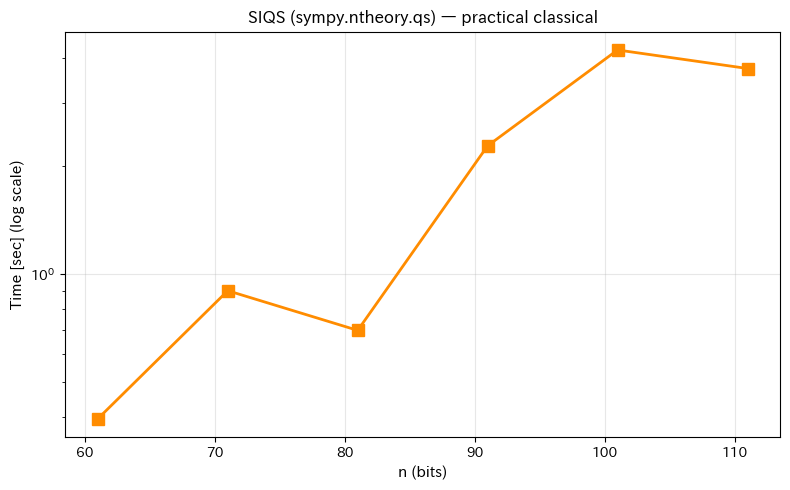


総当たり法が ~27 ビットで限界だったのに対し、SIQS は 100 ビット超に到達できる。
しかし、ビット数の増加とともに計算時間は急増する。
RSA-2048 (2048 ビット) の因数分解は、古典の最良アルゴリズムでも現実的な時間では不可能である。


In [11]:
# === 実用的古典法 (SIQS) の計算時間を計測 ===
# SymPy の qs (Self-Initializing Quadratic Sieve) を使用する。
# 再現性のため、半素数は nextprime で決定的に生成する (毎回同じ値)。

from sympy.ntheory.qs import qs as sympy_qs
from sympy import nextprime

# --- 計測対象の半素数を生成 ---
# p_bits ごとに p = nextprime(2^p_bits), q = nextprime(p + p//3) として n = p*q を作る
# n のビット長 ≈ 2 * p_bits + 1
target_p_bits = [30, 35, 40, 45, 50, 55]  # → n ≈ 61, 71, 81, 91, 101, 111 bit

print("=== SIQS (sympy.ntheory.qs.qs) ===")
print(f"{'n bits':>8s}  {'time':>10s}  {'結果':>10s}")
print("-" * 35)

bit_sizes_qs = []
times_qs = []

for p_bits in target_p_bits:
    p = nextprime(2**p_bits)
    q = nextprime(p + p // 3)
    n = p * q

    t_start = time.perf_counter()
    try:
        # prime_bound: 因子基底の上限, M: 篩う区間の大きさ
        factors = sympy_qs(n, prime_bound=2000, M=10000)
        elapsed = time.perf_counter() - t_start
        # qs は失敗時に [n] を返すため、len >= 2 かつ n 自身でないことを確認
        ok = (len(factors) >= 2 and n not in factors)
        result_str = '成功' if ok else '失敗'
    except Exception:
        elapsed = time.perf_counter() - t_start
        result_str = 'エラー'

    bit_sizes_qs.append(n.bit_length())
    times_qs.append(elapsed)
    print(f"{n.bit_length():>8d}  {elapsed:>9.2f}s  {result_str:>10s}")

# --- グラフを描画 ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(bit_sizes_qs, times_qs, 's-', color='darkorange', linewidth=2, markersize=8)
ax.set_xlabel('n (bits)', fontsize=11)
ax.set_ylabel('Time [sec] (log scale)', fontsize=11)
ax.set_title('SIQS (sympy.ntheory.qs) — practical classical', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("総当たり法が ~27 ビットで限界だったのに対し、SIQS は 100 ビット超に到達できる。")
print("しかし、ビット数の増加とともに計算時間は急増する。")
print("RSA-2048 (2048 ビット) の因数分解は、古典の最良アルゴリズムでも現実的な時間では不可能である。")

---

## **2. 回路実行: Shorのアルゴリズムを動かす**



### **2.1 本章の目的と内容**

1章では、位数さえ分かれば因数分解できることを確認し、素朴な古典的位数探索がすぐ重くなること、さらに古典の実用法が篩法系の工夫によってそれを大きく改善することを見た。それでも古典最良法は準指数時間であり、RSA-2048 には届かない。Shor のアルゴリズムは、この位数探索を量子位相推定 (QPE) によって多項式時間で実現する (→ 本書「量子位相推定」節, 「Shorのアルゴリズム」節) 。ここでは理論の詳細は本編に任せ、回路を組んで動かし、結果を体験することに集中する。

Shorのアルゴリズム全体をどう量子回路として実装するかにはいくつかの実装方式がある。本ハンズオンでは Beauregard (2003) のフーリエ空間算術 (Draper加算器ベースのモジュラー乗算) を用いて回路を構成する。Beauregard の元論文では、QPE の制御ビットを1本に絞り逐次的に再利用することで $2n+3$ 量子ビットまで削減しているが、本ハンズオンでは QPE の仕組みを視覚的に理解しやすくするため、制御レジスタを $M = 2N$ ビット分すべて保持する構成を採用する。そのため、量子ビット数は $4N+2$ となる ($N$ は $n$ を2進数で表すのに必要なビット数。$n=15$ なら $N=4$、合計18量子ビット)。

加算器からモジュラー乗算を構成するという基本構造は Beauregard 方式と同一であり、教材用に簡略化したものではない (実用レベルではさらに最適化された Gidney-Ekerå (2021) 方式などが検討されているが、基本構造は共通している) 。量子ビット数が少ないため $n=15$ でもシミュレータで実行できる。


ここからは、Shorのアルゴリズムの量子回路を以下の6ステップで構成する。

| ステップ | やること | 本書の対応 |
|---------|---------|----------|
| **1. 初期状態の準備** | 制御レジスタ $\lvert 0\rangle^{\otimes M}$ + ターゲットレジスタ $\lvert 1\rangle$ | → 本書「Shorのアルゴリズムの手順」節 ステップ1 |
| **2. アダマールゲート** | 制御レジスタを重ね合わせ状態にする | → 本書「Shorのアルゴリズムの手順」節 ステップ2 |
| **3. 制御モジュラー累乗** | 「$a$ を掛けてmod $n$」を量子ゲートで制御的に適用 ← **QPEの中でのShor固有の部分** | → 本書「Shorのアルゴリズムの手順」節 ステップ3 |
| **4. 逆QFT** | 位相情報を測定可能な形に変換 | → 本書「Shorのアルゴリズムの手順」節 ステップ4 |
| **5. 測定** | 制御レジスタを測定して値 $z$ を取得 | → 本書「Shorのアルゴリズムの手順」節 ステップ5 |
| **6. 連分数展開→因数分解** | $z$ から位数 $r$ を復元し、1章の方法で素因数を求める | → 本書「Shorのアルゴリズムの手順」節 ステップ5–6 |


### **2.2 まずパラメータを設定する**



ここでは一例として、 $n=15, a=7$ を具体例として回路を構成する。\
(※ 以下で構築するコードは $n=15$ 専用ではなく、$n$ (小さな奇数合成数) と $a$ ($\gcd(a, n)=1$) を変えればそのまま別の数でも動く汎用構成である。冒頭の設計方針で述べた通り、$n=15$ 用に最適化したトイ実装 (コンパイル版) とは異なり、回路の構造自体が $n$ をパラメータとして受け取る設計になっている。)

本ハンズオンの実装では以下の4つのレジスタ (特定の役割を持つ量子ビットのまとまり) を使用する。Beauregard の元論文では制御ビットを1本に絞り $2n+3$ 量子ビットで実現しているが、ここでは QPE のフル制御レジスタを保持するため、合計 $4N+2$ 量子ビットとなる。各レジスタのサイズは全て $n$ から自動的に決まる。

| レジスタ | サイズ | 決め方 | $n=15$ の場合 |
|---------|-------|--------|-------------|
| `ctrl` (制御)  | $M = 2N$ | QPEの精度 (→ 本書「Shorのアルゴリズムの手順」節)  | $2 \times 4 = 8$ ビット |
| `x` (ターゲット)  | $N$ ($n$ を2進数で表すのに必要なビット数)  | $n$ のサイズで決まる | $4$ ビット |
| `acc` (加算用)  | $N + 1$ | フーリエ空間加算で使用 | $5$ ビット |
| `anc` (補助)  | $1$ | モジュラー加算の比較用 | $1$ ビット |
| **合計** | **$4N + 2$** | | **$18$ ビット** |

$n=15$ という小さい数でも18量子ビット必要になる。

以下のコードでこれらのパラメータを設定する。

> **やること**\
● $n=15$ と設定し、本実装のレジスタ構成に基づいてサイズを決定する。  
>  ctrl: `M`=8, x: `N`=4, acc: `N_acc`=5, anc: 1

In [12]:
# --- パラメータ設定 ---
import time

n_number = 15
a = 7
assert gcd(a, n_number) == 1, f"a={a} と n={n_number} は互いに素でない (gcd={gcd(a, n_number)})"
N = ceil(log2(n_number))   # 4
M = 2 * N                  # 8
r_true = compute_order(a, n_number)  # 1章の古典計算で位数を求めておく (回路実行後の答え合わせに使う)
shots = 4096

print(f"=== パラメータ ===")
print(f"n = {n_number} (因数分解対象)")
print(f"a = {a} (底)")
print(f"N = {N} (ターゲットレジスタのビット数: ceil(log2({n_number})))")
print(f"M = {M} (制御レジスタのビット数: 2N)")
print()

# レジスタ構成
N_acc = N + 1
print(f"=== レジスタ構成 ===")
print(f"  ctrl:  {M} ビット  (QPEの制御ビット)")
print(f"  x:     {N} ビット  (ターゲット、|1⟩で初期化)")
print(f"  acc:   {N_acc} ビット  (Beauregard方式の加算用)")
print(f"  anc:   1 ビット   (モジュラー加算の補助)")
print(f"  合計:  {M + N + N_acc + 1} 量子ビット")

=== パラメータ ===
n = 15 (因数分解対象)
a = 7 (底)
N = 4 (ターゲットレジスタのビット数: ceil(log2(15)))
M = 8 (制御レジスタのビット数: 2N)

=== レジスタ構成 ===
  ctrl:  8 ビット  (QPEの制御ビット)
  x:     4 ビット  (ターゲット、|1⟩で初期化)
  acc:   5 ビット  (Beauregard方式の加算用)
  anc:   1 ビット   (モジュラー加算の補助)
  合計:  18 量子ビット


### **2.3 ステップ1: 初期状態の準備 (→ 本書「Shorのアルゴリズムの手順」節 ステップ1)**



冒頭で述べた通り、量子計算は「①初期状態の準備 → ②量子ゲートの作用 → ③測定＋古典計算」の3ステップで進む。ここからはこの流れに沿って回路を構成していく。

まず①初期状態の準備として、制御レジスタを $|0\rangle^{\otimes M}$、ターゲットレジスタを $|1\rangle$ に設定する。

ここで $|1\rangle$ とは「整数1を $N$ ビットの2進数で表した状態 $|00\ldots01\rangle$」である (→ 本書「Shorのアルゴリズムの手順」節ステップ1) 。ターゲットレジスタを $|1\rangle$ にするのは、モジュラー乗算演算子の全固有状態を等確率でサンプルするためである (→ 本書「モジュラー乗算演算子」節) 。


実装特有の話だが、Qiskit ではレジスタは自動的に $|0\rangle$ に初期化されるため、ターゲットレジスタの最下位ビットに X ゲート ($|0\rangle$ と $|1\rangle$ を反転するゲート) を適用して $|1\rangle$ を作る。

> **【インデックスの対応について】**\
> 本書では中間状態を $|\psi_0\rangle$ から数えるが、本ハンズオンでは $|\psi_1\rangle$ から数えている。本書の $|\psi_k\rangle$ はハンズオンの $|\psi_{k+1}\rangle$ に対応する（例：本書ステップ1完了時の状態は本書では $|\psi_0\rangle$、ハンズオンでは $|\psi_1\rangle$）。

**ステップ1後の全体状態 (→ 本書「Shorのアルゴリズムの手順」節 式)**

$$|\psi_1\rangle = |0\rangle^{\otimes M}_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}}$$

> **やること**\
● 初期状態 $|0\rangle^{\otimes M}_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}}$ を準備する。本ハンズオンでは、Qiskit の API を使って量子回路を構成する。\
● `QuantumRegister` (量子ビットのまとまりを定義するクラス) で4つのレジスタを作り、`QuantumCircuit` (量子回路を生成するクラス) にまとめる。ターゲットレジスタには X ゲートを適用して $|0\rangle \to |1\rangle$ にセットする。
> **ポイント**\
● Qiskit では全量子ビットが $|0\rangle$ で初期化されるため、ターゲットレジスタの最下位ビットに X ゲートを適用して $|00\ldots0\rangle$ → $|00\ldots1\rangle = |1\rangle$ にする。

In [13]:
# --- ステップ1: 初期状態の準備 ---
from qiskit.quantum_info import Statevector  # 回路の量子状態を取得するクラス

# --- 4つのレジスタを定義 ---
ctrl = QuantumRegister(M, name='ctrl')    # 制御レジスタ: M=8 量子ビット を用意
x = QuantumRegister(N, name='x')          # ターゲットレジスタ: N=4 量子ビット を用意
acc = QuantumRegister(N + 1, name='acc')  # 加算用レジスタ: N+1=5 量子ビット を用意
anc = QuantumRegister(1, name='anc')      # 補助レジスタ: 1 量子ビット (固定)  を用意
c = ClassicalRegister(M, name='meas')     # 古典レジスタ: 測定結果を格納する M=8 ビット (量子ビットではない)  を用意


# どんなオブジェクトか見てみる
print("=== レジスタの中身 ===")
print(f"ctrl: {ctrl}  → {ctrl.size} 量子ビット、名前 '{ctrl.name}'")
print(f"x:    {x}  → {x.size} 量子ビット、名前 '{x.name}'")
print(f"acc:  {acc}  → {acc.size} 量子ビット、名前 '{acc.name}'")
print(f"anc:  {anc}  → {anc.size} 量子ビット、名前 '{anc.name}'")
print(f"c:    {c}  → {c.size} 古典ビット、名前 '{c.name}'")
print()
print(f"量子ビット合計: {ctrl.size + x.size + acc.size + anc.size}")
print(f"古典ビット合計: {c.size}")



=== レジスタの中身 ===
ctrl: QuantumRegister(8, 'ctrl')  → 8 量子ビット、名前 'ctrl'
x:    QuantumRegister(4, 'x')  → 4 量子ビット、名前 'x'
acc:  QuantumRegister(5, 'acc')  → 5 量子ビット、名前 'acc'
anc:  QuantumRegister(1, 'anc')  → 1 量子ビット、名前 'anc'
c:    ClassicalRegister(8, 'meas')  → 8 古典ビット、名前 'meas'

量子ビット合計: 18
古典ビット合計: 8


`QuantumRegister` は「名前のついた量子ビットの集まり」を表す Qiskit のオブジェクトである。この時点ではまだ量子回路には組み込まれておらず、部品として存在するだけである。

以上で4つの量子レジスタと1つの古典レジスタを定義し、中身を確認した。
各レジスタの使い道を下記に簡単にまとめた。

```
最終的な回路の構造

  ctrl (8 量子ビット)  ─── H ─── 制御U ─── IQFT ─── 測定 → c (8 古典ビット)
  x    (4 量子ビット)  ─── X ─── U の対象
  acc  (5 量子ビット)  ─── (Beauregard方式の加算用)
  anc  (1 量子ビット)  ─── (モジュラー加算の符号判定用)
```

次のセルでは、これらのレジスタを `QuantumCircuit` に渡して回路オブジェクトを生成する。Qiskitでは初期状態は常に$|0\rangle$ で固定されている。

型: QuantumCircuit
量子ビット数: 18
古典ビット数: 8
ゲート数: 0 (まだ何も追加していない) 

空の回路:


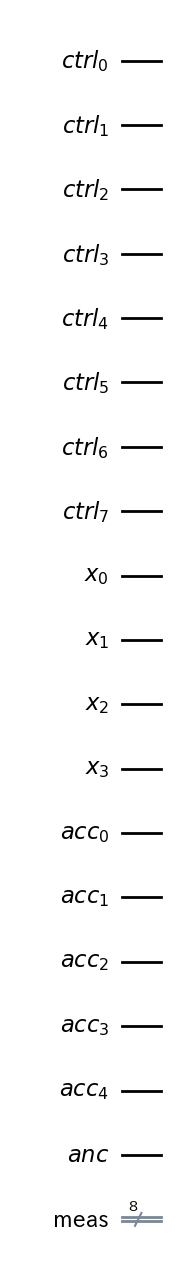

In [14]:
# --- レジスタをまとめて量子回路を生成 ---
# QuantumCircuit にレジスタを渡すと、回路オブジェクトが生成される
# この時点では全量子ビットが |0⟩ で、ゲートは何も入っていない
qc = QuantumCircuit(ctrl, x, acc, anc, c)

# qc がどんなオブジェクトか確認
print(f"型: {type(qc).__name__}")
print(f"量子ビット数: {qc.num_qubits}")
print(f"古典ビット数: {qc.num_clbits}")
print(f"ゲート数: {qc.size()} (まだ何も追加していない) ")
print()

# 空の回路を表示 (全ビットが |0⟩、ゲートなし)
print("空の回路:")
display(qc.draw('mpl'))

# 空の回路を保存 (ステップ1のセルを再実行しても安全なように)
qc_step0 = qc.copy()

回路が生成できたが、量子ビットが $|0\rangle$ の状態で、ゲートはまだ何もない。

今回は、$|\psi_1\rangle = |0\rangle^{\otimes M}_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}}$という状態を用意したいため、`.x()` メソッドでゲートを使って、ターゲットレジスタの最下位ビットに X ゲート (`qc.x(x[0])`) を追加して $|0\rangle \to |1\rangle$ にする。

ステップ1完了: X ゲートを追加して初期状態を準備
  ゲート数: 1 (X ゲートが1つ追加された) 

X ゲート追加後の回路:


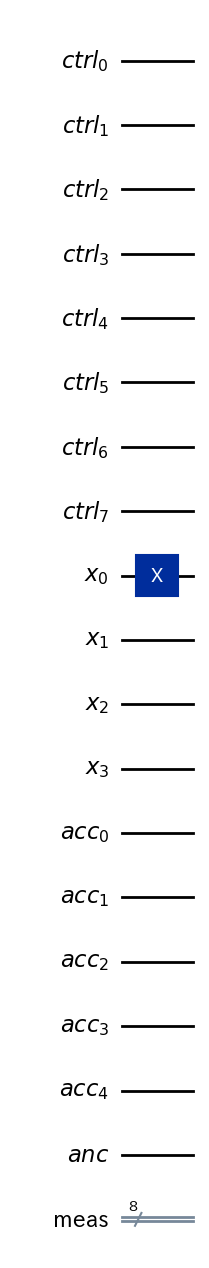

In [15]:
# --- ターゲットレジスタの最下位ビットに X ゲートを適用 ---
# 回路生成時点の状態に戻す (このセルを何度実行しても X が重ねがけされないように)
qc = qc_step0.copy()
# |0000⟩ → |0001⟩ = |1⟩ にする (整数1を4ビット2進数で表した状態)
qc.x(x[0])

print("ステップ1完了: X ゲートを追加して初期状態を準備")
print(f"  ゲート数: {qc.size()} (X ゲートが1つ追加された) ")
print()
print("X ゲート追加後の回路:")
display(qc.draw('mpl'))

# ステップ1完了時点の回路を保存 (後のステップで再実行しても安全なように)
qc_step1 = qc.copy()

回路に X ゲートを追加した。本当にターゲットレジスタが $|1\rangle$ になっているか確認したい。

Qiskit の `Statevector.from_instruction()` を使うと、量子回路の状態ベクトル (各計算基底状態 $|0\rangle, |1\rangle, \ldots$ の振幅) を計算してくれる。振幅が0でない成分だけ見れば、どの状態にあるかが分かる。

In [16]:
# --- 状態ベクトルで初期状態を確認 ---

# 古典レジスタを除いた回路を作る (Statevector は量子ビットのみ扱うため)
qc_no_meas = qc.remove_final_measurements(inplace=False)

# 回路を実行した後の状態ベクトルを取得
sv = Statevector.from_instruction(qc_no_meas)
print(sv)

# 振幅がゼロでない成分だけ表示
print("量子状態の確認 (振幅が0でない状態のみ表示) :")
for i, amp in enumerate(sv):
    if abs(amp) > 1e-10:
        print(f"  |{i}⟩ の振幅 = {amp.real:.0f}  → 確率 {abs(amp)**2:.0f}")
print()
print("→ ターゲットが |1⟩ に初期化されていることを確認できた")

Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
量子状態の確認 (振幅が0でない状態のみ表示) :
  |256⟩ の振幅 = 1  → 確率 1

→ ターゲットが |1⟩ に初期化されていることを確認できた


### **2.4 ステップ2: 制御レジスタにアダマールゲート (→ 本書「Shorのアルゴリズムの手順」節 ステップ2)**



制御レジスタの全ビットにアダマールゲート $H$ を適用し、$|0\rangle^{\otimes M}$ を全計算基底の均等な重ね合わせ $\frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle$ に変換する。

**ステップ2後の全体状態 (→ 本書「Shorのアルゴリズムの手順」節 式)**:

$$|\psi_2\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}}$$

> **やること**\
● 制御レジスタの全 $M=8$ 量子ビットにアダマールゲート $H$ を適用する。\
Qiskit では `qc.h(ctrl)` で制御レジスタ全体に一括適用できる。\
> **ポイント**\
● $H$ は $|0\rangle$ を $(|0\rangle + |1\rangle)/\sqrt{2}$ に変換するゲートで、8ビット全てに適用すると $2^8 = 256$ 状態の均等な重ね合わせになる  

> ※ **重ね合わせだけでは計算は速くならない** (→ 本書「Shorのアルゴリズムの手順」節 ステップ3) \
重ね合わせの式を見ると「$2^M$ 通りの計算を同時に実行している」ように見えるが、測定したら得られるのは1つの値にすぎない。これは古典的な意味での並列計算とは本質的に異なる。量子計算が速い理由は、 (この先で実践していくが) 重ね合わせそのものではなく、量子干渉 (逆QFT) によって正しい答え (位相 $s/r$ に対応する $z$) の確率が増幅され、それ以外が打ち消されることにある。この干渉＋連分数展開の組み合わせで初めて位数 $r$ が取り出せる。

ステップ2完了: 制御レジスタにアダマールゲートを適用
  アダマールゲート数: 8
  現在の回路の合計ゲート数: 9

状態ベクトルの確認:
  振幅が非ゼロの成分数: 256 個 (2^8 = 256 なら正しい) 
  各成分の確率: 0.003906
  全て等確率か: True
  → 制御レジスタが 256 状態の均等な重ね合わせになっている

現在の回路:


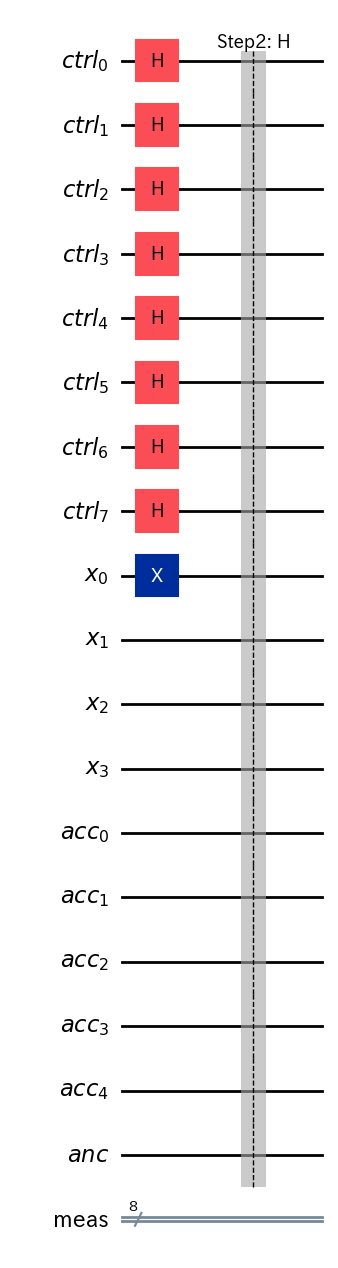

In [17]:
# --- ステップ2: 制御レジスタにアダマールゲート ---

# ステップ1完了時点の回路をコピー (このセルを何度実行しても H が重ねがけされないようにする)
qc = qc_step1.copy()

# ctrl レジスタの全8量子ビットにアダマールゲート H を適用
qc.h(ctrl)

# barrier: 回路図上の区切り線。見やすさのために入れるだけで量子状態には影響しない
qc.barrier(label='Step2: H')

print("ステップ2完了: 制御レジスタにアダマールゲートを適用")
print(f"  アダマールゲート数: {M}")
print(f"  現在の回路の合計ゲート数: {qc.size()}")
print()

# --- ステップ1と同じ方法で状態ベクトルを確認 ---
qc_no_meas = qc.remove_final_measurements(inplace=False)  # 古典レジスタを除く
sv = Statevector.from_instruction(qc_no_meas)               # 状態ベクトルを取得

# 各成分の確率 (振幅の絶対値の2乗) を計算
probs = [abs(amp)**2 for amp in sv]

# 非ゼロの成分を数える
n_nonzero = sum(1 for p in probs if p > 1e-10)

# 全ての非ゼロ成分が同じ確率かどうか確認
nonzero_probs = [p for p in probs if p > 1e-10]
all_equal = all(abs(p - nonzero_probs[0]) < 1e-10 for p in nonzero_probs)

print(f"状態ベクトルの確認:")
print(f"  振幅が非ゼロの成分数: {n_nonzero} 個 (2^{M} = {2**M} なら正しい) ")
print(f"  各成分の確率: {nonzero_probs[0]:.6f}")
print(f"  全て等確率か: {all_equal}")
print(f"  → 制御レジスタが {n_nonzero} 状態の均等な重ね合わせになっている")

print()
print("現在の回路:")
display(qc.draw('mpl'))

# ステップ2完了時点の回路を保存
qc_step2 = qc.copy()

### **2.5 ステップ3の準備: 制御モジュラー乗算を加算器から組み上げる**



#### **ステップ3で追加するゲート**



ステップ2までで、以下の状態の回路を作成した。

$$|\psi_2\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}}$$

ステップ3では、この回路に「制御モジュラー累乗ゲート」を追加して、以下の状態を作りたい。

$$|\psi_3\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes U_{a,n}^z |1\rangle_{\mathcal{N}} = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes |a^z \bmod n\rangle_{\mathcal{N}}$$

つまり、各制御ビット $k$ に応じて $U_{a,n}^{2^k}$ をターゲットに作用させるゲートが必要である。

Qiskit には一般的な乗算回路 (`RGQFTMultiplier` 等) は用意されているが、Shorのアルゴリズムで必要な「定数 $a$ によるモジュラー乗算 $|x\rangle \to |ax \bmod n\rangle$」を直接行う標準ゲートは用意されていない。そのため、より基本的な部品から自分で構成する必要がある。

>「制御ビット $k$ が $|1\rangle$ のときだけターゲットレジスタに $U_{a,n}^{2^k}$ を作用させる」部分については、Qiskit が提供する制御付きゲートの仕組み (`cp` や `PhaseGate.control()` など) を利用する (実機では2量子ビット間の物理的な相互作用を使い実装も複雑だが、本教材ではAPIレベルでどう使うかが分かっていれば十分である) 。



#### **モジュラー乗算はどう分解できるか**



モジュラー乗算を一気に実装するのは難しく感じるが、段階的に分解すると見通しが立つ。

>**① モジュラー乗算 = モジュラー加算の繰り返し**

定数 $c$ と $x$ の乗算 $c \times x$ を考える。$x$ を $N$ ビットの2進数 $x = (x_{N-1} \cdots x_1 x_0)_2 = \sum_k x_k \cdot 2^k$ (各 $x_k$ は 0 か 1) と展開すると以下のように書くことができる。
$$c \times x = c \cdot x_0 + (2c) \cdot x_1 + (4c) \cdot x_2 + \cdots = \sum_k (c \cdot 2^k) \cdot x_k$$
つまり、乗算は「$c \cdot 2^k$ を $x$ のビット $x_k$ に応じて足すかどうか」の繰り返しで実現できる。\
例えば $c=7, x=5=(0101)_2$ なら $7 \times 5 = 7 \cdot 1 + 14 \cdot 0 + 28 \cdot 1 + 56 \cdot 0 = 35$ となる。\
上記の展開式の各足し算を $\bmod n$ で行えばモジュラー乗算になる。この「足し算を $\bmod n$ で行う」部分がモジュラー加算器である。


>**② モジュラー加算 = 加算 + mod の処理**

モジュラー加算 $(b + a) \bmod n$ は、まず $a$ を足してから $n$ を超えていたら $n$ を引き戻す、という手順で実現できる。「$n$ を引く」は「$-n$ を足す」ことなので、これも加算器で実現可能である。


したがって、**加算器さえ実装できれば、②でモジュラー加算、①でモジュラー乗算**と順に構成できる。

>**モジュラー乗算を構築する方針**

以下では **加算 → モジュラー加算 → モジュラー乗算** の順に、基本的な部品から一つずつ実装・動作確認しながら進める。ここで定義する関数はそのまま最終的なShor回路 (ステップ3) の中で使われる。

| Level | やること | 実装する関数 |
|-------|---------|------------|
| Level 0 | 加算 (フーリエ空間)  | `phi_add()` |
| Level 1 | モジュラー加算 ($\bmod n$ 付き)  | `cc_phi_add_mod()` |
| Level 2 | 制御モジュラー乗算 | `c_mult_mod()` |


#### **Level 0: フーリエ空間での定数加算 (Draper加算器)**

それではまず加算器を実装する。\
量子ゲートで足し算を実現する方式はいくつかあるが (桁上がり伝搬加算器など) 、Beauregard方式では**Draper加算器**を採用している。Draper加算器はフーリエ空間で位相回転として足し算を行うため、桁上がりを格納する補助量子ビットが不要であり、回路全体の量子ビット数を抑えられる。


##### **量子ビットの「位相」とは**


Draper加算器のアイデアを理解するには、まず「位相」が何を指すかを押さえる必要がある。

一般の1量子ビット状態は $\alpha|0\rangle + \beta|1\rangle$ ($|\alpha|^2+|\beta|^2=1$) と書けるが、以下で扱う QFT 後の状態は各量子ビットが $\frac{1}{\sqrt{2}}\bigl(|0\rangle + e^{i\varphi}|1\rangle\bigr)$ という等振幅の形をとる。この $\varphi$ を相対位相と呼ぶ。

以下では、QFT がレジスタに格納された数値 $b$ をこの位相にエンコードし、Draper加算器がこの位相を操作することで足し算を実現する仕組みを見る。


##### **量子フーリエ変換の性質: 数値が位相に分配される**


QFT (量子フーリエ変換) は、計算基底状態 $|b\rangle$ (レジスタに格納された数値 $b$) を別の基底に変換する操作である (詳しくは本書「量子位相推定」節に記載されている) 。ここではDraper加算器を理解するために必要な性質だけを押さえる。

QFTの定義は以下のとおりである (→ 本書「量子位相推定」節) 。

$$U_{\text{QFT}}|b\rangle = \frac{1}{\sqrt{2^N}} \sum_{z=0}^{2^N-1} e^{2\pi i b \frac{z}{2^N}} |z\rangle$$

QFTには逆変換 (IQFT: 逆量子フーリエ変換) が存在し、位相にエンコードされた情報を元の計算基底に戻すことができる。\
(Draper加算器では「QFT → 位相操作 → IQFT」の往復を利用する。)

上の式は、以下のような各量子ビットのテンソル積の形に書き直すことができる (標準的な変形であり、量子計算の教科書で広く用いられている) 。

$$U_{\text{QFT}}|b\rangle = \frac{1}{\sqrt{2^N}} \bigotimes_{k=0}^{N-1} \left( |0\rangle + e^{i\varphi_k} |1\rangle \right), \quad \varphi_k = \frac{2\pi \cdot b}{2^{N-k}}$$

つまり、レジスタに格納された数値 $b$ (例えば $|0101\rangle$ なら $b=5$) が、QFTによって各量子ビットの位相 $\varphi_k$ に分配される。Draper加算器はこの性質を利用して、位相を回すだけで足し算を実現する。




##### **Draper加算器: 位相を回すだけで足し算ができる**


QFT後の状態で位相 $\varphi_k$ に $b$ がエンコードされているなら、$\varphi_k$ を少し回して $b+a$ に対応する位相にした後、**IQFT (逆量子フーリエ変換 = QFTの逆変換) で元の計算基底に戻せば $|b+a\rangle$ が得られる**。つまり Draper加算器は QFT → 位相回転 → IQFT という往復で足し算を実現する。これがDraper加算器の核心であり、補助量子ビットが不要なため回路全体の量子ビット数を抑えられる。


では、レジスタに格納されている値 $b$ に定数 $a$ を足して $b + a$ にしたいとする。QFT後の位相は $\varphi_k = 2\pi b / 2^{N-k}$ なので、$b \to b+a$ にするには位相を以下のように回せばよい。

$$\varphi_k \;\to\; \varphi_k + \underbrace{\frac{2\pi \cdot a}{2^{N-k}}}_{\theta_k} = \frac{2\pi \cdot b}{2^{N-k}} + \frac{2\pi \cdot a}{2^{N-k}} = \frac{2\pi \cdot (b+a)}{2^{N-k}}$$

この追加の回転量 $\theta_k$ は $a$ だけで決まり、$b$ には依存しない。



##### **実装: 位相回転による加算を関数にする**


まとめると、Draper加算器による足し算は「QFTで位相空間に変換 → 位相を $\theta_k$ だけ回す → IQFTで元に戻す」という流れで実現できる。

$$|b\rangle \xrightarrow{\text{QFT}} \bigotimes_k (|0\rangle + e^{i\varphi_k}|1\rangle) \xrightarrow{P(\theta_k)} \bigotimes_k (|0\rangle + e^{i(\varphi_k + \theta_k)}|1\rangle) \xrightarrow{\text{IQFT}} |b + a\rangle$$

上の式のうち、QFT と IQFT は Qiskit に既に用意されている (`QFT` クラス) 。自分で実装する必要があるのは、真ん中の **位相を $\theta_k$ だけ回す部分** である。これには以下の2つの関数を作る必要がある。

1. **$\theta_k$ を計算する** (足す数 $a$ からどれだけ位相を回すかを求める) \
→ `get_angles` 関数
2. **$\theta_k$ で位相を回す** (回路に位相ゲート $P(\theta_k)$ を追加する) \
→ `phi_add` 関数

| 関数 | 入力 | 出力 | やっていること |
|------|------|------|--------------|
| `get_angles(a, N)` | 足す数 $a$、ビット数 $N$ | 各ビットの回転量のリスト $[\theta_0, \theta_1, \ldots, \theta_{N-1}]$ | 上の式の $\theta_k = 2\pi \cdot a / 2^{N-k}$ を計算する |
| `phi_add(qc, angles, qubits)` | 量子回路 `qc`、角度リスト `angles`、対象量子ビット |  (回路に位相ゲートを追加)  | 各ビットに $P(\theta_k)$ を適用する。つまり $\varphi_k \to \varphi_k + \theta_k$ を実行する |

次のセルでこの2つの関数を定義し、`get_angles` がどんな $\theta_k$ を返すかを確認する。その後、QFT → `phi_add` → IQFT の一連の流れを回路として組み、実際に足し算ができるかを全パターンで検証する。

> **やること**\
● 足す数 $a$ から各ビットの位相回転量 $\theta_k$ を計算する関数を定義する → `get_angles(a, N)`\
● 計算された $\theta_k$ を Qiskit の位相ゲート `P(θ)` (量子ビットの位相を $\theta$ だけ回転させるゲート) として回路に追加する関数を定義する → `phi_add(qc, angles, qubits)`\
● $a=3, N=4$ で `get_angles` を実行し、各 $\theta_k$ の値を確認する  


In [18]:
# --- get_angles: θ_k = 2π·a / 2^(N-k) を計算する ---
def get_angles(a, n_bits):
    """各ビット k の位相回転量 θ_k = 2π·a / 2^(N-k) を計算して返す"""
    angles = np.zeros(n_bits)
    for k in range(n_bits):
        angles[k] = 2 * np.pi * a / (2 ** (n_bits - k))
    return angles


# --- phi_add: 計算された θ_k で位相ゲートを適用する ---
def phi_add(qc, angles, target_qubits):
    """フーリエ空間で定数加算: 各ビットに P(θ_k) を適用する"""
    for i in range(len(target_qubits)):
        if abs(angles[i]) > 1e-15:
            qc.p(angles[i], target_qubits[i])


# --- get_angles の動作確認 (本番とは別の値で試す) ---
demo_bits = 3   # 3ビットのレジスタを想定
demo_a = 5      # 定数 5 を足す場合
demo_angles = get_angles(demo_a, demo_bits)

print(f"動作確認: get_angles(a={demo_a}, n_bits={demo_bits}) の結果:")
print()
for k in range(demo_bits):
    print(f"  k={k}: θ_{k} = 2π·{demo_a}/2^{demo_bits-k} = {demo_angles[k]:.4f} rad")
print()
print("phi_add はこの角度で P(θ_k) を各ビットに適用する関数。")

動作確認: get_angles(a=5, n_bits=3) の結果:

  k=0: θ_0 = 2π·5/2^3 = 3.9270 rad
  k=1: θ_1 = 2π·5/2^2 = 7.8540 rad
  k=2: θ_2 = 2π·5/2^1 = 15.7080 rad

phi_add はこの角度で P(θ_k) を各ビットに適用する関数。


##### **Draper加算器の回路を組んで動かす**

`get_angles` と `phi_add` を使って、実際に加算回路を組んでみる。

$|b\rangle \xrightarrow{QFT} \xrightarrow{phi\_add(a)} \xrightarrow{IQFT} |b+a\rangle$

まず $b=5, a=3$ の具体例で回路図を確認し、その後全パターンで検証する。

> **やること**\
● 4ビットのレジスタに値 $b$ をセットし、QFT → `phi_add`($a=3$) → IQFT の回路を実行して、出力が $b+3$ になるか確認する。(回路図も確認) \
● $b = 0, 1, 2, \ldots, 15$ の全16通り (4ビットで表せる全ての値) を試し正しい結果が得られているかどうかを確認する。

> ※ ここで組む回路は本筋の Shor 回路とは別のテスト用回路であり、`phi_add` の正常性を確認するためのものである。

回路図 (b=5, a=3 の例):


/tmp/ipykernel_2371/2669756734.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_demo.append(QFT(demo_circuit_bits), range(demo_circuit_bits))  # QFT (デフォルト: スワップあり)
/tmp/ipykernel_2371/2669756734.py:22: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_demo.append(QFT(demo_circuit_bits).inverse(), range(demo_circuit_bits))  # IQFT


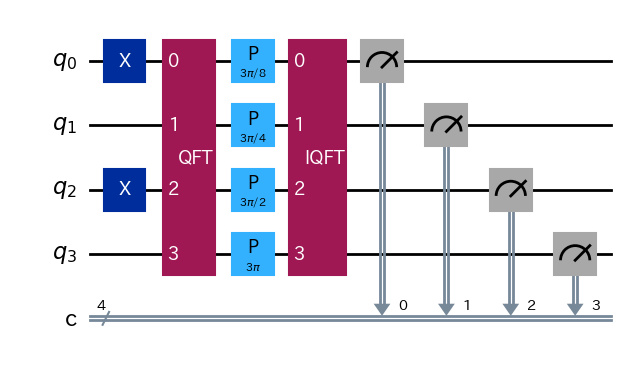

/tmp/ipykernel_2371/2669756734.py:53: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


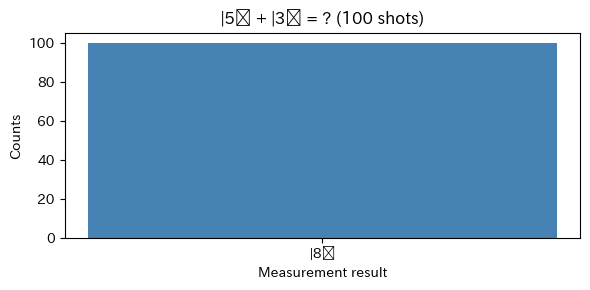

In [19]:
# --- テスト用回路: b=5 に a=3 を足す ---

# テスト用のパラメータ (本筋の Shor 回路とは別)
demo_circuit_bits = 4
demo_circuit_a = 3

# 先ほど定義した get_angles で θ_k を計算
demo_circuit_angles = get_angles(demo_circuit_a, demo_circuit_bits)

# Qiskit の QuantumCircuit でテスト用の4ビット回路を生成
qc_demo = QuantumCircuit(demo_circuit_bits, demo_circuit_bits)

# |b=5⟩ = |0101⟩ を準備
# 5 の2進数表現で 1 が立っているビットに X ゲートを適用
for i in range(demo_circuit_bits):
    if (5 >> i) & 1:      # 5 を右に i ビットシフトして最下位が 1 か判定
        qc_demo.x(i)

# QFT → phi_add(3) → IQFT の流れを回路に追加
qc_demo.append(QFT(demo_circuit_bits), range(demo_circuit_bits))  # QFT (デフォルト: スワップあり)
phi_add(qc_demo, demo_circuit_angles, list(range(demo_circuit_bits)))              # 自作関数: 位相を θ_k 回転
qc_demo.append(QFT(demo_circuit_bits).inverse(), range(demo_circuit_bits))  # IQFT

# .measure(量子ビット, 古典ビット): 量子ビット0,1,2,3 を測定し、古典ビット0,1,2,3 にそれぞれ格納する
# range(4) = [0,1,2,3] なので、各量子ビットと古典ビットが1対1で対応する
qc_demo.measure(range(demo_circuit_bits), range(demo_circuit_bits))

# 回路図を表示
print("回路図 (b=5, a=3 の例):")
display(qc_demo.draw('mpl'))

# --- ここから実行: 作成した回路をシミュレータで動かす ---

# AerSimulator: Qiskit が提供する量子回路シミュレータ (実機の代わり)
sim_demo = AerSimulator(seed_simulator=SEED)

# sim_demo.run: 回路を実行し、demo_shots 回測定して結果の分布を見る
demo_shots = 100
qc_demo_t = transpile(qc_demo, sim_demo, optimization_level=0)
result_demo = sim_demo.run(qc_demo_t, shots=demo_shots, seed_simulator=SEED).result()

# 測定結果は {'1000': 100} のような辞書 (ビット列: 出現回数) で返る
counts_demo = result_demo.get_counts()

# 分布をグラフで表示
labels = [f"|{int(bs, 2)}⟩" for bs in counts_demo.keys()]
values = list(counts_demo.values())
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(labels, values, color='steelblue')
ax.set_xlabel('Measurement result')
ax.set_ylabel('Counts')
ax.set_title(f'|5⟩ + |3⟩ = ? ({demo_shots} shots)')
plt.tight_layout()
plt.show()

上記の $b=5$ の例では、100回測定して全て $|8\rangle$ が出た。少なくともこの例では正しく加算ができている。\
理論的には、QFT → `phi_add` → IQFT の操作は入力 $|b\rangle$ を $|b+a\rangle$ に変換し、重ね合わせにはならないため、理想的には何回測定しても必ず同じ結果になる。

これを前提として、以下では $b = 0, 1, \ldots, 15$ の全16通りについて1回ずつ測定し、全てで足し算が正しく行われることを確認する。

In [20]:
# --- 全パターンで検証 ---
# 上の処理を関数にして、b=0〜15 の全パターンで回す

def run_draper_add(b, a, n_bits, sim):
    """Draper加算器で |b⟩ + a を計算し、測定結果 (整数) を返す"""
    angles = get_angles(a, n_bits)
    qc = QuantumCircuit(n_bits, n_bits)
    for i in range(n_bits):
        if (b >> i) & 1:
            qc.x(i)
    qc.append(QFT(n_bits), range(n_bits))
    phi_add(qc, angles, list(range(n_bits)))
    qc.append(QFT(n_bits).inverse(), range(n_bits))
    qc.measure(range(n_bits), range(n_bits))
    qc_t = transpile(qc, sim, optimization_level=0)
    result = sim.run(qc_t, shots=1, seed_simulator=SEED).result()
    return int(list(result.get_counts().keys())[0], 2)


verify_bits = 4
verify_a = 3
sim_verify = AerSimulator(seed_simulator=SEED)

print(f"=== 全パターン検証: {verify_bits}ビット, a={verify_a} ===")
print()

errors = 0
for b in range(2**verify_bits):       # b = 0, 1, 2, ..., 15
    expected = (b + verify_a) % (2**verify_bits)  # 普通の足し算で期待値を計算 (4ビットなので16以上はオーバーフローして0に戻る)
    measured = run_draper_add(b, verify_a, verify_bits, sim_verify)  # 量子回路で計算
    # 量子回路の結果と期待値を比較
    ok = "OK" if measured == expected else "NG"
    if measured != expected:
        errors += 1
    print(f"  |{b}⟩ + {verify_a} = |{measured}⟩  (期待: |{expected}⟩)  {ok}")

print()
if errors == 0:
    print(f"全 {2**verify_bits} パターンで成功!")
    print("→ phi_add による位相回転で、任意の入力に対して正しく足し算ができている。")

/tmp/ipykernel_2371/265890515.py:11: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_bits), range(n_bits))
/tmp/ipykernel_2371/265890515.py:13: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_bits).inverse(), range(n_bits))


=== 全パターン検証: 4ビット, a=3 ===

  |0⟩ + 3 = |3⟩  (期待: |3⟩)  OK
  |1⟩ + 3 = |4⟩  (期待: |4⟩)  OK
  |2⟩ + 3 = |5⟩  (期待: |5⟩)  OK
  |3⟩ + 3 = |6⟩  (期待: |6⟩)  OK
  |4⟩ + 3 = |7⟩  (期待: |7⟩)  OK
  |5⟩ + 3 = |8⟩  (期待: |8⟩)  OK
  |6⟩ + 3 = |9⟩  (期待: |9⟩)  OK
  |7⟩ + 3 = |10⟩  (期待: |10⟩)  OK
  |8⟩ + 3 = |11⟩  (期待: |11⟩)  OK
  |9⟩ + 3 = |12⟩  (期待: |12⟩)  OK
  |10⟩ + 3 = |13⟩  (期待: |13⟩)  OK
  |11⟩ + 3 = |14⟩  (期待: |14⟩)  OK
  |12⟩ + 3 = |15⟩  (期待: |15⟩)  OK
  |13⟩ + 3 = |0⟩  (期待: |0⟩)  OK
  |14⟩ + 3 = |1⟩  (期待: |1⟩)  OK
  |15⟩ + 3 = |2⟩  (期待: |2⟩)  OK

全 16 パターンで成功!
→ phi_add による位相回転で、任意の入力に対して正しく足し算ができている。


##### **制御付き加算器の作成**

Shor の回路の「モジュラー加算 (Level 1)」では、別の量子ビット (制御ビット) の状態に応じて、ターゲットレジスタに「足す/足さない」を切り替える「制御付き加算器」が必要になる。

`phi_add` が「ターゲットレジスタに定数 $a$ を常に足す」だったのに対し、制御付き版は「制御ビット (別のレジスタ上の量子ビット) が $|1\rangle$ のときだけターゲットレジスタに定数 $a$ を足し、$|0\rangle$ のときは何もしない」。制御ビットが重ね合わせ状態でも、$|0\rangle$ 成分と $|1\rangle$ 成分に対して異なる操作が同時に行われる。



> **やること**\
● 制御ビットが $|1\rangle$ のときだけ加算する関数 `c_phi_add` を Qiskit の `cp(θ, ctrl, target)` を使用して定義する。\
● 同様に、2つの制御ビットが両方 $|1\rangle$ のときだけ加算する関数 `cc_phi_add` を `PhaseGate(θ).control(2)` を使用して定義する。

In [21]:
# --- 1制御ビット版 ---
# PhaseGate(θ).control(1) で位相ゲートに制御ビットを1つ付ける
def c_phi_add(qc, angles, ctrl_qubit, target_qubits):
    """1制御ビット付き加算: ctrl が |1⟩ のときだけ位相を回転"""
    for i in range(len(target_qubits)):
        if abs(angles[i]) > 1e-15:
            gate = PhaseGate(angles[i]).control(1)
            qc.append(gate, [ctrl_qubit, target_qubits[i]])


# --- 2制御ビット版 ---
# PhaseGate(θ).control(2) で位相ゲートに制御ビットを2つ付ける
def cc_phi_add(qc, angles, ctrl1, ctrl2, target_qubits):
    """2制御ビット付き加算: ctrl1 と ctrl2 が両方 |1⟩ のときだけ位相を回転"""
    for i in range(len(target_qubits)):
        if abs(angles[i]) > 1e-15:
            gate = PhaseGate(angles[i]).control(2)
            qc.append(gate, [ctrl1, ctrl2, target_qubits[i]])

##### **制御付き加算器の動作確認 (`c_phi_add` )**

$|b\rangle$ に定数 $a$ を足す加算 ($|b\rangle \to |b+a\rangle$) が、制御ビットが $|1\rangle$ のときだけ行われ、$|0\rangle$ のときは何もしないことを確認する。

> ※ テスト用回路であり、本筋の Shor 回路とは別。

In [22]:
# --- c_phi_add の動作確認 ---
test_bits = 4
test_a = 3
test_b = 5
test_angles = get_angles(test_a, test_bits)
sim_ctrl = AerSimulator(seed_simulator=SEED)

# === ケース1: 制御ビット = |0⟩ (加算されないはず) ===
qc_ctrl0 = QuantumCircuit(1 + test_bits, test_bits)
ctrl_idx = 0
tgt_indices = list(range(1, 1 + test_bits))
# 制御ビットは |0⟩ のまま (デフォルト)
# ターゲットに |b=5⟩ = |0101⟩ をセット
for i in range(test_bits):
    if (test_b >> i) & 1:
        qc_ctrl0.x(tgt_indices[i])
qc_ctrl0.append(QFT(test_bits), tgt_indices)
c_phi_add(qc_ctrl0, test_angles, ctrl_idx, tgt_indices)
qc_ctrl0.append(QFT(test_bits).inverse(), tgt_indices)
qc_ctrl0.measure(tgt_indices, range(test_bits))

result0 = sim_ctrl.run(transpile(qc_ctrl0, sim_ctrl, optimization_level=0), shots=1, seed_simulator=SEED).result()
measured0 = int(list(result0.get_counts().keys())[0], 2)
print(f"ctrl=|0⟩: |{test_b}⟩ → |{measured0}⟩  → {'変化なし' if measured0 == test_b else 'NG'}")

# === ケース2: 制御ビット = |1⟩ (加算されるはず) ===
qc_ctrl1 = QuantumCircuit(1 + test_bits, test_bits)
ctrl_idx = 0
tgt_indices = list(range(1, 1 + test_bits))
qc_ctrl1.x(ctrl_idx)  # 制御ビットを |0⟩ → |1⟩ にセット
for i in range(test_bits):
    if (test_b >> i) & 1:
        qc_ctrl1.x(tgt_indices[i])
qc_ctrl1.append(QFT(test_bits), tgt_indices)
c_phi_add(qc_ctrl1, test_angles, ctrl_idx, tgt_indices)
qc_ctrl1.append(QFT(test_bits).inverse(), tgt_indices)
qc_ctrl1.measure(tgt_indices, range(test_bits))

result1 = sim_ctrl.run(transpile(qc_ctrl1, sim_ctrl, optimization_level=0), shots=1, seed_simulator=SEED).result()
measured1 = int(list(result1.get_counts().keys())[0], 2)
print(f"ctrl=|1⟩: |{test_b}⟩ → |{measured1}⟩  → {test_b}+{test_a}={test_b+test_a}")

print()
print("→ 制御ビットが |1⟩ のときだけ加算され、|0⟩ のときは何もしない。")

ctrl=|0⟩: |5⟩ → |5⟩  → 変化なし


/tmp/ipykernel_2371/99462715.py:17: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_ctrl0.append(QFT(test_bits), tgt_indices)
/tmp/ipykernel_2371/99462715.py:19: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_ctrl0.append(QFT(test_bits).inverse(), tgt_indices)
/tmp/ipykernel_2371/99462715.py:34: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all p

ctrl=|1⟩: |5⟩ → |8⟩  → 5+3=8

→ 制御ビットが |1⟩ のときだけ加算され、|0⟩ のときは何もしない。


一方で、制御ビットが重ね合わせ状態の時も考える。\
制御ビットにアダマールゲートを適用して $(|0\rangle + |1\rangle)/\sqrt{2}$ にすると、制御付き加算を適用する前の状態は以下の通りである。

$$\frac{1}{\sqrt{2}}\left(|0\rangle_{\text{ctrl}} + |1\rangle_{\text{ctrl}}\right) \otimes |5\rangle_{\text{target}}$$

制御ビットとターゲットは独立 (積状態) である。ここに `c_phi_add` を適用すると以下のように計算できる。

$$\frac{1}{\sqrt{2}}\left(|0\rangle_{\text{ctrl}} \otimes |5\rangle + |1\rangle_{\text{ctrl}} \otimes |8\rangle\right)$$

$|0\rangle$ 成分には加算が作用せず $|5\rangle$ のまま、$|1\rangle$ 成分には加算が作用して $|8\rangle$ になる。\
上記の状態では、ターゲットを測定すると、$|5\rangle$ と $|8\rangle$ がそれぞれ確率 $1/2$ で出るはずである。次のセルで実際に500回測定して、本当に約半々の分布になるかを確認する。

> ※ 上の状態 $(|0\rangle|5\rangle + |1\rangle|8\rangle)/\sqrt{2}$ は、制御ビットとターゲットレジスタが**エンタングル** (量子もつれ) した状態である。すなわち、全体の状態が $|\psi\rangle_{\text{ctrl}} \otimes |\phi\rangle_{\text{target}}$ の形に分解できない。ハンズオンを進める上ではエンタングルメントの詳細を理解する必要はないが、興味のある方は → 本書「Shorのアルゴリズムの手順」節 コラム「$|\psi_2\rangle$ はエンタングルメント状態」を参照されたい。

/tmp/ipykernel_2371/3251408529.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_H.append(QFT(test_bits), tgt_indices)
/tmp/ipykernel_2371/3251408529.py:18: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_H.append(QFT(test_bits).inverse(), tgt_indices)
/tmp/ipykernel_2371/3251408529.py:34: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) IPAexGothic.
  plt.tight_layout()


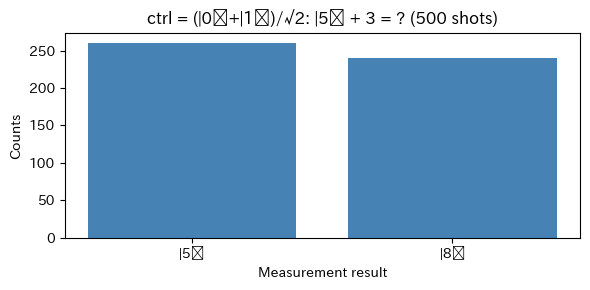

→ |5⟩ (足されない) と |8⟩ (足された) が約半々で出現。


In [23]:
# --- 制御ビットを重ね合わせにして c_phi_add を適用 ---
# 前のセルとの違いは制御ビットの初期化だけ:
#   前のセル: qc.x(ctrl_idx)  → |1⟩ にセット
#   このセル: qc.h(ctrl_idx)  → (|0⟩+|1⟩)/√2 にセット

qc_H = QuantumCircuit(1 + test_bits, test_bits)
ctrl_idx = 0
tgt_indices = list(range(1, 1 + test_bits))

qc_H.h(ctrl_idx)  # ← ここだけが違う: |0⟩ → (|0⟩+|1⟩)/√2

# 以下は前のセルと同じ
for i in range(test_bits):
    if (test_b >> i) & 1:
        qc_H.x(tgt_indices[i])
qc_H.append(QFT(test_bits), tgt_indices)
c_phi_add(qc_H, test_angles, ctrl_idx, tgt_indices)
qc_H.append(QFT(test_bits).inverse(), tgt_indices)
qc_H.measure(tgt_indices, range(test_bits))

# 重ね合わせなので複数回測定して分布を見る
H_shots = 500
result_H = sim_ctrl.run(transpile(qc_H, sim_ctrl, optimization_level=0), shots=H_shots, seed_simulator=SEED).result()
counts_H = result_H.get_counts()

# 分布をグラフで表示
labels = [f"|{int(bs, 2)}⟩" for bs in sorted(counts_H.keys())]
values = [counts_H[bs] for bs in sorted(counts_H.keys())]
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(labels, values, color='steelblue')
ax.set_xlabel('Measurement result')
ax.set_ylabel('Counts')
ax.set_title(f'ctrl = (|0⟩+|1⟩)/√2: |{test_b}⟩ + {test_a} = ? ({H_shots} shots)')
plt.tight_layout()
plt.show()

print(f"→ |{test_b}⟩ (足されない) と |{test_b+test_a}⟩ (足された) が約半々で出現。")

##### **制御付き加算器の動作確認 (`cc_phi_add` )**

`cc_phi_add` は2つの制御ビットが**両方** $|1\rangle$ のときだけ加算する。4つのパターン $(|0\rangle,|0\rangle), (|1\rangle,|0\rangle), (|0\rangle,|1\rangle), (|1\rangle,|1\rangle)$ を全て試して確認する。

/tmp/ipykernel_2371/1704446607.py:21: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(test_bits), tgt_indices)
/tmp/ipykernel_2371/1704446607.py:23: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(test_bits).inverse(), tgt_indices)
/tmp/ipykernel_2371/1704446607.py:48: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) IPAexGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET})

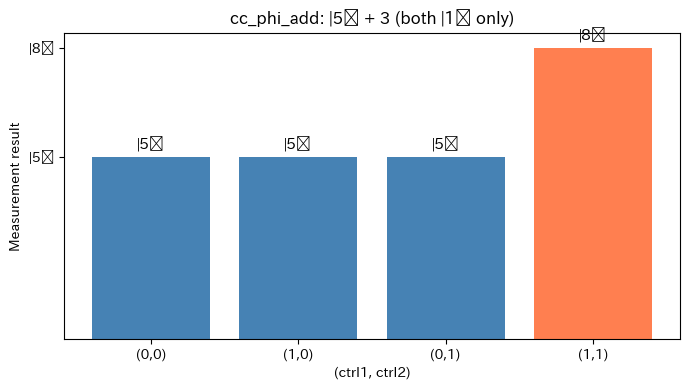

→ (1,1) のときだけ |5⟩ → |8⟩ に変化 (AND条件) 。
  それ以外は |5⟩ のまま。


In [24]:
# --- cc_phi_add の動作確認: 4パターン ---
# c_phi_add と同じ構造だが、制御ビットが2つ。両方 |1⟩ のときだけ加算される。

patterns = [(0,0), (1,0), (0,1), (1,1)]
results_cc = {}

for c1, c2 in patterns:
    qc = QuantumCircuit(2 + test_bits, test_bits)
    ctrl1_idx, ctrl2_idx = 0, 1
    tgt_indices = list(range(2, 2 + test_bits))

    if c1 == 1:
        qc.x(ctrl1_idx)
    if c2 == 1:
        qc.x(ctrl2_idx)

    for i in range(test_bits):
        if (test_b >> i) & 1:
            qc.x(tgt_indices[i])

    qc.append(QFT(test_bits), tgt_indices)
    cc_phi_add(qc, test_angles, ctrl1_idx, ctrl2_idx, tgt_indices)
    qc.append(QFT(test_bits).inverse(), tgt_indices)
    qc.measure(tgt_indices, range(test_bits))

    result = sim_ctrl.run(transpile(qc, sim_ctrl, optimization_level=0), shots=1, seed_simulator=SEED).result()
    measured = int(list(result.get_counts().keys())[0], 2)
    results_cc[(c1,c2)] = measured

# 結果をグラフで表示
labels = [f"({c1},{c2})" for c1, c2 in patterns]
values = [results_cc[p] for p in patterns]
colors = ['steelblue' if v == test_b else 'coral' for v in values]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colors)
ax.set_xlabel('(ctrl1, ctrl2)')
ax.set_ylabel('Measurement result')
ax.set_title(f'cc_phi_add: |{test_b}⟩ + {test_a} (both |1⟩ only)')
ax.set_yticks(sorted(set(values)))
ax.set_yticklabels([f"|{v}⟩" for v in sorted(set(values))])

# 各棒に値を表示
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"|{v}⟩", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f"→ (1,1) のときだけ |{test_b}⟩ → |{test_b+test_a}⟩ に変化 (AND条件) 。")
print(f"  それ以外は |{test_b}⟩ のまま。")

#### **ここまでの準備と次のステップ**



Level 0 でフーリエ空間での加算 (`phi_add`) と、その制御付き版 (`c_phi_add`, `cc_phi_add`) ができた。しかし、Shorのアルゴリズムでは普通の加算ではなく 「$\bmod n$ 付きの加算」が必要である。次の Level 1 では、Level 0 の加算を部品として使い、$(b + a) \bmod n$ を実現する。



#### **Level 1: フーリエ空間でのモジュラー加算**



Level 0 で「フーリエ空間での加算」ができるようになった。次は、これに **$\bmod n$ の処理**を加えて $(b + a) \bmod n$ を計算する。




##### **モジュラー加算のアイデア**



$(b + a) \bmod n$ を実現するには、以下の手順を踏めばよい。

1. **$a$ を足す**\
Level 0 の `cc_phi_add` で $(b + a)$ を計算
2. **$n$ を引く**\
`phi_add` で $-n$ を足して $(b + a - n)$ にする
3. **結果が負かどうか判定**\
$(b + a - n) < 0$ なら $n$ を引きすぎたので $n$ を足し戻す

この「負かどうかの判定」に補助ビット (アンシラと呼ぶ) を使う。フーリエ空間から一度戻して最上位ビット (符号ビット) を確認し、再びフーリエ空間に戻す、という操作が求められる。

> **やること**\
● 上の手順1–3を Qiskit で実装したモジュラー加算の関数 `cc_phi_add_mod`を作成する。\
● その逆演算 `cc_phi_add_mod_inv` を定義する。量子ゲートはユニタリであり逆変換 ($U^\dagger$) が必ず存在するので、`cc_phi_add_mod` で使った各ゲートの逆が取れ、逆ゲートを逆順に並べるだけで逆演算が構成できる。Level 2 の内部で必要になる


In [25]:
# --- Level 1: モジュラー加算 ---
# Level 0 の関数を組み合わせて (b+a) mod n を実現する。
# 上で説明した手順1–3がそのままコードになっている。

def cc_phi_add_mod(qc, a_val, n_val, ctrl1, ctrl2, target_qubits, ancilla):
    """二重制御モジュラー加算: (b + a) mod n をフーリエ空間で計算する

    引数:
        qc: 量子回路
        a_val: 足す定数
        n_val: モジュラスn
        ctrl1, ctrl2: 制御ビット (両方|1⟩のとき加算)
        target_qubits: 加算対象のレジスタ (フーリエ空間にある前提)
        ancilla: 補助ビット (符号判定に使用)
    """
    n_bits = len(target_qubits)
    angles_a = get_angles(a_val, n_bits)       # +a の角度
    angles_n = get_angles(n_val, n_bits)       # +n の角度
    angles_neg_a = get_angles((2**n_bits) - a_val, n_bits)  # -a の角度
    angles_neg_n = get_angles((2**n_bits) - n_val, n_bits)  # -n の角度

    # --- 手順1: a を足す (ctrl1, ctrl2 が両方|1⟩のときだけ) ---
    cc_phi_add(qc, angles_a, ctrl1, ctrl2, target_qubits)

    # --- 手順2: n を引く (無条件で引く) ---
    phi_add(qc, angles_neg_n, target_qubits)

    # --- 手順3: 結果が負かどうか判定し、負なら n を足し戻す ---
    qc.append(QFT(n_bits).inverse(), target_qubits)  # フーリエ→計算基底
    qc.cx(target_qubits[n_bits - 1], ancilla)  # 最上位ビット (符号) をアンシラにコピー (2の補数表現では最上位1=負)
    qc.append(QFT(n_bits), target_qubits)            # 計算基底→フーリエ
    # アンシラが1 (=結果が負だった) なら n を足し戻す
    # ここで c_phi_add の制御ビットとして ancilla を使っている
    c_phi_add(qc, angles_n, ancilla, target_qubits)

    # --- アンシラを |0⟩ に戻す (アンコンピュート) ---
    # 手順3でアンシラが |1⟩ になった場合、このまま残すと他のレジスタとエンタングルした状態になり、以降の計算結果が壊れる。
    # そのため |0⟩ に戻す必要があるが、量子ゲートにそのような操作は存在しない。
    # 代わりに、ユニタリ操作だけで |0⟩ に戻す手法を使う。
    # これはアンコンピュートと呼ばれ、量子計算で補助ビットを扱う際の一般的な原則である。
    #
    # ① ターゲットを「手順1で a を足す前の状態 b」に一時的に戻す
    cc_phi_add(qc, angles_neg_a, ctrl1, ctrl2, target_qubits)  # (b+a) mod n → b に戻す
    #
    # ② 戻した状態 b の符号ビットを使って、アンシラを |0⟩ に戻す
    #    b >= 0 なので符号ビットは 0。X ゲートで反転してから cx でアンシラに作用させ、再度 X で戻す
    qc.append(QFT(n_bits).inverse(), target_qubits)  # フーリエ→計算基底
    qc.x(target_qubits[n_bits - 1])            # 符号ビットを反転 (0→1)
    qc.cx(target_qubits[n_bits - 1], ancilla)  # アンシラが |1⟩ なら |0⟩ に戻る
    qc.x(target_qubits[n_bits - 1])            # 符号ビットを元に戻す (1→0)
    qc.append(QFT(n_bits), target_qubits)           # 計算基底→フーリエ
    #
    # ③ ターゲットを最終結果 (b+a) mod n に再び進める
    cc_phi_add(qc, angles_a, ctrl1, ctrl2, target_qubits)     # b → (b+a) mod n に戻す


def cc_phi_add_mod_inv(qc, a_val, n_val, ctrl1, ctrl2, target_qubits, ancilla):
    """cc_phi_add_mod の逆演算: 上の全操作を逆順に実行"""
    n_bits = len(target_qubits)
    angles_a = get_angles(a_val, n_bits)
    angles_n = get_angles(n_val, n_bits)
    angles_neg_a = get_angles((2**n_bits) - a_val, n_bits)
    angles_neg_n = get_angles((2**n_bits) - n_val, n_bits)

    cc_phi_add(qc, angles_neg_a, ctrl1, ctrl2, target_qubits)
    qc.append(QFT(n_bits).inverse(), target_qubits)
    qc.x(target_qubits[n_bits - 1])
    qc.cx(target_qubits[n_bits - 1], ancilla)
    qc.x(target_qubits[n_bits - 1])
    qc.append(QFT(n_bits), target_qubits)
    cc_phi_add(qc, angles_a, ctrl1, ctrl2, target_qubits)
    c_phi_add(qc, angles_neg_n, ancilla, target_qubits)
    qc.append(QFT(n_bits).inverse(), target_qubits)
    qc.cx(target_qubits[n_bits - 1], ancilla)
    qc.append(QFT(n_bits), target_qubits)
    phi_add(qc, angles_n, target_qubits)
    cc_phi_add(qc, angles_neg_a, ctrl1, ctrl2, target_qubits)


print("Level 1 関数を定義しました")
print("  cc_phi_add_mod:     (b + a) mod n を計算")
print("  cc_phi_add_mod_inv: 上の逆演算")

Level 1 関数を定義しました
  cc_phi_add_mod:     (b + a) mod n を計算
  cc_phi_add_mod_inv: 上の逆演算


##### **モジュラー加算の動作確認**



`cc_phi_add_mod` が正しく $(b + a) \bmod n$ を計算するかを確認する。

> **やること**\
cc_phi_add_modを利用して、  $(b + a) \bmod n$ を計算する

> ※ テスト用回路であり、本筋の Shor 回路とは別。

In [26]:
# --- Level 1 の動作確認: 1つの具体例で確認 ---
# 以下の変数を自由に変えて別パターンもお試しあれ
test_n = 7    # モジュラス n
test_a = 5    # 足す定数 a
test_b = 3    # 入力値 b
expected = (test_b + test_a) % test_n  # 古典計算での期待値

N_mod = ceil(log2(test_n))
n_acc = N_mod + 1

# テスト回路: 制御ビット2つ + アキュムレータ(n_acc) + アンシラ(1)
qc_mod = QuantumCircuit(2 + n_acc + 1, n_acc)
ctrl1_idx, ctrl2_idx = 0, 1
acc_indices = list(range(2, 2 + n_acc))
anc_idx = 2 + n_acc

# 制御ビットを両方 |1⟩ にセット (cc_phi_add_mod が動く条件)
qc_mod.x(ctrl1_idx)
qc_mod.x(ctrl2_idx)

# ターゲットに |b⟩ をセット
for i in range(n_acc):
    if (test_b >> i) & 1:
        qc_mod.x(acc_indices[i])

# QFT → cc_phi_add_mod → IQFT → 測定
qc_mod.append(QFT(n_acc), acc_indices)
cc_phi_add_mod(qc_mod, test_a, test_n, ctrl1_idx, ctrl2_idx, acc_indices, anc_idx)
qc_mod.append(QFT(n_acc).inverse(), acc_indices)
qc_mod.measure(acc_indices, range(n_acc))

sim_mod = AerSimulator(seed_simulator=SEED)
result_mod = sim_mod.run(transpile(qc_mod, sim_mod, optimization_level=0), shots=1, seed_simulator=SEED).result()
measured = int(list(result_mod.get_counts().keys())[0], 2)

print(f"({test_b} + {test_a}) mod {test_n} = {measured}  (期待: {expected})  {'OK!' if measured == expected else 'NG'}")

/tmp/ipykernel_2371/1470716205.py:27: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_mod.append(QFT(n_acc), acc_indices)
/tmp/ipykernel_2371/3746608931.py:29: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_bits).inverse(), target_qubits)  # フーリエ→計算基底
/tmp/ipykernel_2371/3746608931.py:31: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to

(3 + 5) mod 7 = 1  (期待: 1)  OK!


#### **ここまでの準備と次のステップ**



Shor回路の部品として、Level 0 (加算) → Level 1 (モジュラー加算) と組み上げてきた。Level 1 で $(b + a) \bmod n$ のモジュラー加算ができたので、次はこれを繰り返してモジュラー乗算を実現する。

ステップ3の準備で述べた通り、モジュラー乗算 $c \times x \bmod n$ はモジュラー加算の繰り返しで実現できる。

$$c \times x \bmod n = \sum_k (c \cdot 2^k) \cdot x_k \bmod n$$

つまり、$x$ の各ビット $x_k$ を制御ビットとして、$c \cdot 2^k$ のモジュラー加算を繰り返せばよい。これが Level 2 の `c_mult_mod` であり、Shor回路のステップ3では、ステップ2までに構成してきた回路にこの関数を組み込んで制御モジュラー累乗 $U_{a,n}^{2^k}$ を実現する。





#### **Level 2: 制御モジュラー乗算**



##### **制御モジュラー乗算の定義**



**⭐実装上の注意**

Level 0/1 では「制御ビット」と「加算先のレジスタ」は別物だった。しかし Level 2 のモジュラー乗算では、$|x\rangle$ の各ビットがモジュラー加算の制御ビットとしても使われ、$|x\rangle$ は制御ビットと計算結果の格納先を兼ねることになる。$|x\rangle$ の各ビットを制御ビットとして順に使っている最中に $|x\rangle$ の値が変わると、後続のビットの制御が壊れてしまうため、加算の結果を $|x\rangle$ には直接書き込めない。

Beauregard方式では、この問題を「別のレジスタ $|acc\rangle$」を使い、以下の手順で対応する。

1. モジュラー加算の結果を $|acc\rangle$ に蓄積する\
$|acc\rangle = |c \cdot x \bmod n\rangle$となる。ここで、$|x\rangle$ は変えない
2. $|x\rangle$ と $|acc\rangle$ の中身を入れ替える (cswap)
3. $|acc\rangle$ に残った元の値を $|0\rangle$ に戻す (アンコンピュート)

これにより、最終的に $|x\rangle$ に計算結果 $|c \cdot x \bmod n\rangle$ が入り、$|acc\rangle$ は $|0\rangle$ に戻る。



In [27]:
# --- Level 2: 制御モジュラー乗算 ---
def c_mult_mod(qc, a_val, a_inv_val, n_val, ctrl_qubit, x_qubits, acc_qubits, ancilla):
    """制御モジュラー乗算: ctrl=|1⟩ のとき |x⟩ → |a_val*x mod n⟩
     (a_val は前のセルの説明における定数 c に対応する。Shor のステップ3では c = a^{2^k} mod n として呼ばれる)

    引数:
        a_val: 掛ける定数 c
        a_inv_val: c の逆元 c⁻¹ mod n (後半のアンコンピュートで使用)
        n_val: モジュラス n
        ctrl_qubit: 制御ビット
        x_qubits: 入力 |x⟩ のレジスタ (最終的にここに c·x mod n が入る)
        acc_qubits: 加算用レジスタ (中間計算に使い、最後に |0⟩ に戻す)
        ancilla: 補助ビット (モジュラー加算の符号判定に使用)
    """
    n_x = len(x_qubits)
    n_acc = len(acc_qubits)

    # --- ブロック1: c·x mod n を acc に計算する ---
    # x の各ビット x_i を制御ビットとして a_val·2^i のモジュラー加算を繰り返す
    qc.append(QFT(n_acc), acc_qubits)  # acc をフーリエ空間に変換
    for i in range(n_x):
        a_shifted = (pow(2, i, n_val) * a_val) % n_val  # a_val·2^i mod n
        cc_phi_add_mod(qc, a_shifted, n_val, ctrl_qubit, x_qubits[i], acc_qubits, ancilla)
    qc.append(QFT(n_acc).inverse(), acc_qubits)  # フーリエ→計算基底に戻す

    # ブロック1完了時点: |x⟩ = 元の x のまま, |acc⟩ = a_val·x mod n (モジュラー加算の結果が蓄積された)

    # --- ブロック2: x と acc を入れ替える ---
    # 入れ替え前: x = 元の x, acc = c·x mod n
    # 入れ替え後: x = c·x mod n (これが欲しい結果) , acc = 元の x
    for i in range(n_x):
        qc.cswap(ctrl_qubit, x_qubits[i], acc_qubits[i])

    # ブロック2完了時点: |x⟩ = a_val·x mod n (欲しい結果) , |acc⟩ = 元の x (これを |0⟩ に戻す必要がある)

    # --- ブロック3: acc を |0⟩ に戻す (アンコンピュート) ---
    # acc には元の x が残っている。a_val の逆元 a_inv_val を使って
    # 逆演算 (cc_phi_add_mod_inv) で acc を |0⟩ に戻す
    qc.append(QFT(n_acc), acc_qubits)
    for i in range(n_x - 1, -1, -1):
        a_inv_shifted = (pow(2, i, n_val) * a_inv_val) % n_val  # a_inv_val·2^i mod n
        cc_phi_add_mod_inv(qc, a_inv_shifted, n_val, ctrl_qubit, x_qubits[i], acc_qubits, ancilla)
    qc.append(QFT(n_acc).inverse(), acc_qubits)


print("Level 2 関数を定義しました: c_mult_mod")

Level 2 関数を定義しました: c_mult_mod


##### **制御モジュラー乗算の動作確認**

`c_mult_mod` が $|x\rangle \to |c \cdot x \bmod n\rangle$ を正しく実現しているか、具体例で確認する。以下の変数を変えれば他の値でも試せる。

> ※ テスト用回路であり、本筋の Shor 回路とは別。

In [28]:
# --- Level 2 の動作確認: |x⟩ → |c·x mod n⟩ ---
test_c, test_n, test_x = 7, 15, 3  # 7×3=21, 21 mod 15=6 (mod が効く例)
test_c_inv = pow(test_c, -1, test_n)  # c の逆元 (c_mult_mod 内のアンコンピュートで必要)
N_cm = ceil(log2(test_n))   # n を2進数で表すビット数 (ceil = 切り上げ)
n_acc_cm = N_cm + 1            # acc レジスタのビット数

qc_cm = QuantumCircuit(1 + N_cm + n_acc_cm + 1, N_cm)
qc_cm.x(0)                                          # 制御ビット = |1⟩
for i in range(N_cm):
    if (test_x >> i) & 1: qc_cm.x(1 + i)            # |x=3⟩ をセット
c_mult_mod(qc_cm, test_c, test_c_inv, test_n, 0,
           list(range(1, 1+N_cm)), list(range(1+N_cm, 1+N_cm+n_acc_cm)), 1+N_cm+n_acc_cm)
qc_cm.measure(list(range(1, 1+N_cm)), list(range(N_cm)))

measured = int(list(AerSimulator(seed_simulator=SEED).run(transpile(qc_cm, AerSimulator(), optimization_level=0), shots=1, seed_simulator=SEED).result().get_counts().keys())[0], 2)
expected = (test_c * test_x) % test_n
print(f"|{test_x}⟩ → |{measured}⟩  (期待: |{expected}⟩ = |{test_c}×{test_x} mod {test_n}⟩)  {'OK!' if measured == expected else 'NG'}")

/tmp/ipykernel_2371/544285794.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_acc), acc_qubits)  # acc をフーリエ空間に変換
/tmp/ipykernel_2371/3746608931.py:29: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_bits).inverse(), target_qubits)  # フーリエ→計算基底
/tmp/ipykernel_2371/3746608931.py:31: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, f

|3⟩ → |6⟩  (期待: |6⟩ = |7×3 mod 15⟩)  OK!


**ステップ3: 制御モジュラー累乗 (→ 本書「Shorのアルゴリズムの手順」節 ステップ3)**





直前のセルで、モジュラー乗算 $|x\rangle \to |c \cdot x \bmod n\rangle$ を実現する `c_mult_mod` を実装し、動作確認を終えた。

本ハンズオンでは、Shorのアルゴリズムを以下の6ステップに分けて実装している。 (→ 本書「Shorのアルゴリズムの手順」節。本ハンズオンでは「回路実行」セクション冒頭の表を参照)

1. ~~初期状態の準備~~ ✓
2. ~~アダマールゲート~~ ✓
3. **制御モジュラー累乗** ← いまここ
4. 逆QFT
5. 測定
6. 連分数展開→因数分解


ステップ3では、ステップ2までに構成した Shor 回路において、ターゲットレジスタを $|1\rangle$ から $|a^z \bmod n\rangle$ に変換したい。

$$|\psi_2\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}} \quad \xrightarrow{\text{ステップ3}} \quad |\psi_3\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes |a^z \bmod n\rangle_{\mathcal{N}}$$

`c_mult_mod` は定数 $c$ を古典的に事前計算して渡す関数である。しかし、ここでの $z$ は制御レジスタの量子状態であり、$|0\rangle + |1\rangle + \cdots + |2^M - 1\rangle$ の重ね合わせになっている。$z$ の値は測定するまで確定しないので、$c = a^z$ を事前に計算して用意しておくことはできない。

ここで、$z$ の2進展開を利用して $a^z$ を分解してみる。

$$z = z_0 \cdot 2^0 + z_1 \cdot 2^1 + \cdots + z_k \cdot 2^k + \cdots + z_{M-1} \cdot 2^{M-1}$$



$$a^z = (a^{2^0})^{z_0} \cdot (a^{2^1})^{z_1} \cdots (a^{2^k})^{z_k} \cdots (a^{2^{M-1}})^{z_{M-1}}$$

各 $z_k$ は制御レジスタの $k$ 番目の量子ビットの状態 ($|0\rangle$ か $|1\rangle$) に対応する。つまり、$z_k = |1\rangle$ のときだけ $a^{2^k}$ を掛けるようにすれば、全体として目的の $|a^z \bmod n\rangle$ への変換が実現できる。

実装について、制御レジスタの $|z\rangle$ は実際には $|z_0\rangle \otimes |z_1\rangle \otimes \cdots \otimes |z_{M-1}\rangle$ であり、各 $|z_k\rangle$ は Qiskit の `ctrl[k]` として個別にアクセスできる。したがって、`ctrl[k]` を制御ビットとして `c_mult_mod` を呼べば、`ctrl[k]` $= |1\rangle$ のときだけ $a^{2^k}$ が掛かる。$c = a^{2^k} \bmod n$ は各 $k$ について古典計算で事前に求められる定数なので、$k = 0, 1, \ldots, M-1$ の全てについて、M個の `c_mult_mod` を回路に追加すればよい。

> **やること**:
> - $a^{2^k} \bmod n$ を $k=0,\ldots,M-1$ について古典計算で事前に求める
> - 各 $k$ で `c_mult_mod(c=a^{2^k})` を `ctrl[k]` を制御ビットとして回路に追加する

> このステップの実行には数秒かかります。

In [29]:
# --- ステップ3: 制御モジュラー累乗 ---
# ステップ2完了時点から開始 (再実行しても安全)
qc = qc_step2.copy()

# --- 古典前計算: 各 k について c = a^{2^k} mod n を求める ---
for k in range(M):
    c_k = pow(a, 1 << k, n_number)  # 1 << k は 2^k と同じ (ビットシフト)
    print(f"  k={k}: c = {a}^(2^{k}) mod {n_number} = {c_k}")
print()

# --- M 個の c_mult_mod を回路に追加 ---
# 各 k について ctrl[k] (制御レジスタの k 番目のビット = z_k) を制御ビットとして
# c_mult_mod(c = a^{2^k}) を回路に追加する
print("制御モジュラー累乗を適用中...")
t_start = time.time()
for k in range(M):
    c_k = pow(a, 1 << k, n_number)        # c = a^{2^k} mod n
    c_k_inv = pow(c_k, -1, n_number)        # c_k の逆元 (c_mult_mod 内のアンコンピュートで使用)
    # ctrl[k] が |1⟩ のときだけ、ターゲットに ×c_k を掛ける
    c_mult_mod(qc, c_k, c_k_inv, n_number, ctrl[k], list(x), list(acc), anc[0])
qc.barrier(label='Step3: CU')
t_step3 = time.time() - t_start

print(f"ステップ3完了: {t_step3:.2f}秒")
print(f"  現在の回路 — ゲート数: {qc.size()},  深さ: {qc.depth()}")
print()
print("現在の回路 (ステップ3まで) :")
fig = qc.draw('mpl', fold=40)
fig.savefig('step3_circuit.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'回路図を step3_circuit.png に保存しました (ノートブックには埋め込まず、ファイルとして保存)')

# ステップ3完了時点の回路を保存
qc_step3 = qc.copy()

  k=0: c = 7^(2^0) mod 15 = 7
  k=1: c = 7^(2^1) mod 15 = 4
  k=2: c = 7^(2^2) mod 15 = 1
  k=3: c = 7^(2^3) mod 15 = 1
  k=4: c = 7^(2^4) mod 15 = 1
  k=5: c = 7^(2^5) mod 15 = 1
  k=6: c = 7^(2^6) mod 15 = 1
  k=7: c = 7^(2^7) mod 15 = 1

制御モジュラー累乗を適用中...


/tmp/ipykernel_2371/544285794.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_acc), acc_qubits)  # acc をフーリエ空間に変換
/tmp/ipykernel_2371/3746608931.py:29: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_bits).inverse(), target_qubits)  # フーリエ→計算基底
/tmp/ipykernel_2371/3746608931.py:31: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, f

ステップ3完了: 0.68秒
  現在の回路 — ゲート数: 2185,  深さ: 1665

現在の回路 (ステップ3まで) :
回路図を step3_circuit.png に保存しました (ノートブックには埋め込まず、ファイルとして保存)


ステップ1〜3を通じて、回路は以下の状態を実現した。

$$|\psi_3\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle \otimes |a^z \bmod n\rangle$$

$n=15, a=7$ の場合、制御レジスタの各 $|z\rangle$ に対応するターゲットの値は以下の通りである。

| $z$ | 0 | 1 | 2 | 3 | **4** | 5 | 6 | 7 | **8** | … |
|-----|---|---|---|---|-------|---|---|---|-------|---|
| $7^z \bmod 15$ | 1 | 7 | 4 | 13 | **1** | 7 | 4 | 13 | **1** | … |

上記を見ると、$z=4$ ごとに同じパターンが繰り返している。つまり、位数 $r=4$ の情報がこの周期構造に埋め込まれている。

しかし、このまま制御レジスタを測定すると $z = 0, 1, 2, \ldots, 255$ が等確率で出るだけであり、周期 $r$ を読み取ることはできない。

次のステップ4で逆量子フーリエ変換 (IQFT) を適用し、この周期構造を「特定の $z$ にピークが立つ」分布に変換する。

### **ステップ4: 逆量子フーリエ変換 (→ 本書「Shorのアルゴリズムの手順」節 ステップ4)**



前のセルで見た通り、ステップ3の状態をそのまま測定しても $z$ は等確率で出るだけであり、周期 $r$ を読み取れない。

逆量子フーリエ変換 (IQFT) は、制御レジスタの周期構造を「特定の $z$ にピークが立つ」分布に変換する操作である (→ 本書「量子位相推定」節) 。具体的には、IQFT 適用後に制御レジスタを測定すると、$z = s \cdot 2^M / r$ ($s = 0, 1, \ldots, r-1$) の $r$ 箇所にピークが集中する。

$n=15, r=4, M=8$ の場合は以下のようになる。

| $s$ | 測定値 $z = s \cdot 2^M / r$ | $z / 2^M$ |
|-----|-------------------------------|----------|
| 0 | $0$ | $0$ |
| 1 | $64$ | $0.25 = 1/4$ |
| 2 | $128$ | $0.50 = 2/4$ |
| 3 | $192$ | $0.75 = 3/4$ |

$z / 2^M = s/r$ の分母に位数 $r$ が現れる。ここから $r$ を復元できる (→ ステップ6で連分数展開を使う) 。

Qiskit では `QFT(...).inverse()` で IQFT の回路が自動生成される。

> **やること**\
● 制御レジスタに IQFT を適用する  
● 次のステップ5では、制御レジスタを測定し、上の表の通り $z = 0, 64, 128, 192$ にピークが立つことを確認する。

In [30]:
# --- ステップ4: 逆量子フーリエ変換 ---
# ステップ3完了時点から開始 (再実行しても安全)
qc = qc_step3.copy()

# M ビットの逆QFT回路を生成 (QFT の逆演算)
iqft = QFT(M).inverse()
iqft.name = 'IQFT'

# 制御レジスタ ctrl に IQFT を適用 (周期構造 → 測定可能なピークに変換)
qc.append(iqft, ctrl)
qc.barrier(label='Step4: IQFT')

print("ステップ4完了: 制御レジスタに逆QFTを適用")
print(f"  現在の回路 — ゲート数: {qc.size()},  深さ: {qc.depth()}")
print()
print("現在の回路 (ステップ4まで) :")
fig = qc.draw('mpl', fold=40)
fig.savefig('step4_circuit.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'回路図を step4_circuit.png に保存しました (ノートブックには埋め込まず、ファイルとして保存)')

# ステップ4完了時点の回路を保存 (次のステップ5で使う)
qc_step4 = qc.copy()

/tmp/ipykernel_2371/634622621.py:6: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(M).inverse()


ステップ4完了: 制御レジスタに逆QFTを適用
  現在の回路 — ゲート数: 2186,  深さ: 1666

現在の回路 (ステップ4まで) :
回路図を step4_circuit.png に保存しました (ノートブックには埋め込まず、ファイルとして保存)


### **ステップ5: 測定 (→ 本書「Shorのアルゴリズムの手順」節 ステップ5)**



ステップ4で IQFT を適用したことで、制御レジスタの状態は $z = \frac{s \cdot 2^M}{r}$ ($s = 0, 1, \ldots, r-1$) の $r$ 箇所にピークが集中する分布になっているはずである。$n=15, r=4, M=8$ の場合、$z = 0, 64, 128, 192$ の4箇所である。

しかし、量子状態は測定するまで確定しない。ここで制御レジスタの $M=8$ ビットを測定し、実際に $z$ の値を取り出す。これが Shor 回路の最終ステップである。

実際の Shor のアルゴリズムでは、回路を1回実行して $z$ を1つ得る。$z \neq 0$ であれば、連分数展開で位数 $r$ を復元し、高い確率で因数分解できる。$n=15, r=4$ の場合、$s = 1, 2, 3$ のいずれかが出れば成功であり、1回の実行で $\frac{3}{4} = 75\%$ の確率で因数分解に成功する。たとえ失敗 ($s=0$) しても、もう一度実行すればよい (→ 成功確率の詳細は本書「成功確率と全体の計算量」節) 。

本ハンズオンでは、この確率分布が理論予測と一致することを体感するために、同じ回路を複数回 (shots 回) 実行してヒストグラムを描く。





#### **Shorのアルゴリズムの回路の完成**

Qiskit では `qc.measure(量子レジスタ, 古典レジスタ)` で測定ゲートを追加できる。

> **やること**\
● 制御レジスタに測定ゲートを追加し、回路を完成させる  

In [31]:
# --- ステップ5: 測定 ---
# ステップ4完了時点から開始 (再実行しても安全)
qc = qc_step4.copy()

# 制御レジスタ ctrl を測定し、結果を古典レジスタ c に格納するように準備
# ※ qc.measure() は回路に測定ゲートを追加するだけで、この時点では実行されない
#   実際の測定は、次のセルで sim.run(qc, shots=...) としてシミュレータに渡したときに行われる
qc.measure(ctrl, c)

print("完成した回路:")
fig = qc.draw('mpl', fold=40)
fig.savefig('step5_circuit.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'回路図を step5_circuit.png に保存しました (ノートブックには埋め込まず、ファイルとして保存)')

完成した回路:
回路図を step5_circuit.png に保存しました (ノートブックには埋め込まず、ファイルとして保存)


#### **Shorのアルゴリズムの実行**

ステップ1–5で回路が完成した。ステップ5で述べた通り、Shor のアルゴリズムは1回の実行でも因数分解に成功し得るが、ここでは測定値 $z$ の分布が理論予測と一致するかを確認するために、同じ回路を $\text{shots} = 4096$ 回繰り返し実行する。

理論の予測 (→ 本書「Shorのアルゴリズムの手順」節) では、IQFT 後の測定値は $z = \frac{s \cdot 2^M}{r}$ ($s = 0, 1, \ldots, r-1$) の $r$ 箇所に等確率 $\frac{1}{r}$ でピークが立つ。$n=15, a=7, r=4, M=8$ の場合、$z = 0, 64, 128, 192$ の4箇所に各 $\frac{1}{4}$ の確率で現れるはずである。

理想シミュレータ (ノイズなし) で実行し、この予測を検証する。

> **やること**\
● 完成した回路を理想シミュレータで $\text{shots} = 4096$ 回実行する\
> **ポイント**\
● 横軸を測定値 $z$ ($0$〜$255$) 、縦軸を出現回数としたヒストグラムにおいて、$z = 0, 64, 128, 192$ の4箇所に約 $1024$ 回ずつ集中している

シミュレーション実行中 (4096 shots)...
シミュレーション完了: 8.5秒

=== 測定結果 (上位10件) ===
    z     z/2^M    カウント       理論ピーク
----------------------------------------
  192    0.7500    1053         s=3
    0    0.0000    1027         s=0
   64    0.2500    1018         s=1
  128    0.5000     998         s=2


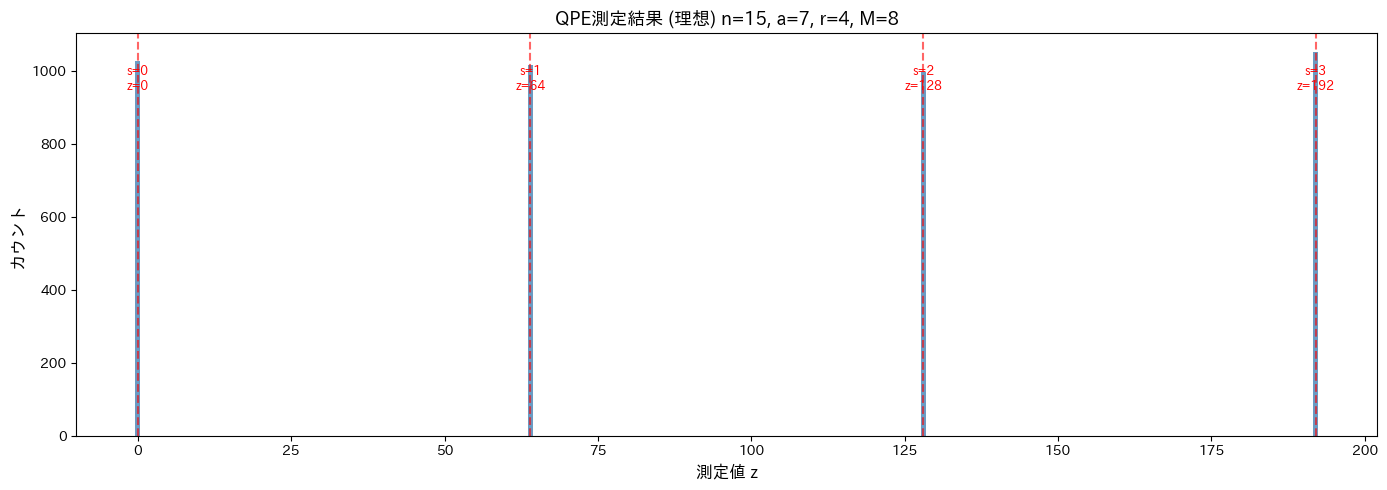

理論ピーク位置: z = s·2^M/r = [0, 64, 128, 192]
対応する位相: s/r = ['0/4', '1/4', '2/4', '3/4']


In [32]:
# --- 理想シミュレータで実行 ---

# ノイズなしのシミュレータを用意（SEED で再現性を確保）
sim_ideal = AerSimulator(seed_simulator=SEED)

# 完成した回路 qc を shots 回実行し、測定値の分布を得る
print(f"シミュレーション実行中 ({shots} shots)...")
t_start = time.time()
qc_ideal_t = transpile(qc, sim_ideal, optimization_level=0)
result_ideal = sim_ideal.run(qc_ideal_t, shots=shots, seed_simulator=SEED).result()
counts_ideal = result_ideal.get_counts()  # {'ビット列': 出現回数} の辞書
print(f"シミュレーション完了: {time.time() - t_start:.1f}秒")

# --- 測定結果をテーブルで表示 ---
# 理論的なピーク位置: z = s * 2^M / r （s = 0, 1, ..., r-1）
expected_peaks = {round(s * 2**M / r_true): s for s in range(r_true)}

print(f"\n=== 測定結果 (上位10件) ===")
print(f"{'z':>5s}  {'z/2^M':>8s}  {'カウント':>6s}  {'理論ピーク':>10s}")
print("-" * 40)

sorted_counts = sorted(counts_ideal.items(), key=lambda x: x[1], reverse=True)
for bitstring, count in sorted_counts[:10]:
    z = int(bitstring, 2)          # ビット列を整数に変換
    phi = z / (2 ** M)             # z/2^M = s/r に対応する値
    peak_str = f"s={expected_peaks[z]}" if z in expected_peaks else ""
    print(f"{z:>5d}  {phi:>8.4f}  {count:>6d}  {peak_str:>10s}")

# --- ヒストグラムの描画 ---
# 横軸: 測定値 z（0〜255）、縦軸: 出現回数
fig, ax = plt.subplots(figsize=(14, 5))

z_values = {}
for bitstring, count in counts_ideal.items():
    z = int(bitstring, 2)
    z_values[z] = z_values.get(z, 0) + count

zs = sorted(z_values.keys())
counts_list = [z_values[z] for z in zs]

ax.bar(zs, counts_list, color='steelblue', alpha=0.8)

# 理論ピーク位置に赤い破線を重ねる
for s in range(r_true):
    z_exp = round(s * 2**M / r_true)
    ax.axvline(x=z_exp, color='red', linestyle='--', alpha=0.6)
    ax.text(z_exp, max(counts_list) * 0.9, f's={s}\nz={z_exp}',
            ha='center', fontsize=9, color='red')

ax.set_xlabel('測定値 z', fontsize=12)
ax.set_ylabel('カウント', fontsize=12)
ax.set_title(f'QPE測定結果 (理想) n={n_number}, a={a}, r={r_true}, M={M}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"理論ピーク位置: z = s·2^M/r = {[round(s * 2**M / r_true) for s in range(r_true)]}")
print(f"対応する位相: s/r = {[f'{s}/{r_true}' for s in range(r_true)]}")

### **測定値$z$から位数$r$を求めるには**

ここまでで、Shor のアルゴリズムの量子パートが完了した。$n=15, a=7$ の具体例で回路をステップ1–5まで組み上げ、実行した結果、測定値 $z = 0, 64, 128, 192$ の4箇所にピークが立つことを確認した\
 (※ 理想シミュレータなので理論通りになるのは当然だが、回路実装の検証と後のノイズ実験のベースラインとしての意味がある) 。

しかし、この時点ではまだ「$z$ という整数が得られた」だけであり、素因数 $p, q$ は求まっていない。1章で確認した通り、位数 $r$ さえ分かれば因数分解できるため、古典計算で $z$ から $r$ を復元する必要がある。



ここで、$z$とは何だったかを思い出す。ステップ1–5で行ったのは量子位相推定 (QPE) である。QPE はモジュラー乗算演算子 $U_{a,n}$ の固有値 $e^{2\pi i s/r}$ の位相 $\frac{s}{r}$ を読み出す仕組みであり (→ 本書「モジュラー乗算演算子」節) 、測定値 $z$ は位相を $2^M$ 倍した以下の整数である。

$$z = \frac{s \cdot 2^M}{r}$$

 (※ 制御レジスタが $M$ ビットなので、$0$〜$1$ の位相を $0$〜$2^M-1$ の整数にマッピングしている。→ 本書「量子位相推定」節) \
つまり、測定値$z$を$2^M$ で割れば $\frac{s}{r}$ が得られ、その分母が位数 $r$である。あとはこの分母を取り出せればよく、次のステップ6で実装する。

$$z \xrightarrow{\div 2^M} \frac{s}{r} \xrightarrow{\text{分母を取り出す}} r \xrightarrow{\text{1章の方法}} p, q$$

### **ステップ6: 連分数展開で測定値から位数を復元し、因数分解する (→ 本書「Shorのアルゴリズムの手順」節 ステップ5–6)**

それでは、$\frac{z}{2^M} = \frac{s}{r}$ の分母 $r$ を取り出したい。ここで、$s \cdot 2^M$ が $r$ で割り切れる場合は単純な約分で済むが、割り切れない場合は $z$ が $\frac{s \cdot 2^M}{r}$ の近似値になるため、正確な分母を復元する工夫 (連分数展開) が必要になる。

**⭐ 割り切れる場合 (今回の $n=15$ がこれに該当)**

例えば $z=64, M=8$ なら単純な割り算だけで位数が求まる。


$$\frac{z}{2^M} = \frac{64}{256} = \frac{1}{4} \quad \Rightarrow \quad \text{分母} = 4 = r$$


**⭐ 割り切れない場合**

一般に、$2^M / r$ が整数にならない場合、$z$ は $\frac{s \cdot 2^M}{r}$ を四捨五入した整数になるため、$\frac{z}{2^M}$ は $\frac{s}{r}$ の近似値にすぎない。この近似値から正確な分母 $r$ を復元するのが連分数展開である。

連分数展開とは、実数を「整数部分を取り出し、残りの逆数を取る」操作を繰り返して以下の形に分解する手法である。

$$\frac{z}{2^M} = a_0 + \cfrac{1}{a_1 + \cfrac{1}{a_2 + \cdots}}$$


制御レジスタのビット数 $M$ が因数分解対象 $n$ に対して $M \geq 2\lceil \log_2 n \rceil$ を満たせば、連分数展開の収束分数に $\frac{s}{r}$ (またはその約分) が現れることが保証されている。今回は $M = 8 \geq 2\lceil \log_2 15 \rceil = 8$ なのでこの条件を満たす。詳しくは本書「Shorのアルゴリズムの手順」節を参照されたい。

**実装について**

Python では `Fraction(z, 2**M).limit_denominator(n)` で、分母が $n$ 以下の最良近似分数が得られる。その分母が位数 $r$ (またはその約数) になる。

以下では、測定値 $z$ から位数復元 → 因数分解までを行う関数を実装し、具体例で確認する。

> **やること**\
● 測定値 $z$ から位数 $r$ を復元し因数分解まで行う関数 `classify_measurement` を実装する。割り切れる場合も割り切れない場合も、`Fraction.limit_denominator`で統一的に処理できる。\
● $z=64$ の例で $r=4$ が復元され、$15 = 3 \times 5$ が求まることを確認する。

In [33]:
# --- ステップ6: 測定値 → 位数復元 → 因数分解 ---

def classify_measurement(z: int, M_ctrl: int, a: int, n: int, max_mult: int = None) -> dict:
    """測定値 z から位数 r を復元し、因数分解を試みる (本書「Shorのアルゴリズムの手順」節 ステップ5-6) """

    # max_mult のデフォルトを n にする (一般の n で取りこぼしを防ぐため)
    if max_mult is None:
        max_mult = n

    # ① z/2^M を計算
    phi = z / (2 ** M_ctrl)

    # z=0 の場合は位相が 0 なので位数を復元できない
    if z == 0:
        return {'z': z, 'phi': phi, 'r': None,
                'factors': None, 'status': 'alg_fail_2_phase0'}

    # ② 連分数展開で分母を取り出す
    #    Fraction(z, 2**M_ctrl) で正確な有理数 z/2^M を作り、
    #    limit_denominator(n) で分母が n 以下の最良近似分数を返す
    frac = Fraction(z, 2 ** M_ctrl).limit_denominator(n)
    r_base = frac.denominator

    # ③ r_base が位数 r そのものとは限らない (r の約数の場合がある)
    #    例: s/r = 2/4 → 約分されて 1/2 → r_base=2 だが真の位数は r=4
    #    そこで r_base の倍数を試し、位数かのチェック : a^r_try ≡ 1 (mod n) を満たすものを探す
    r = None
    for mult in range(1, max_mult + 1):
        r_try = r_base * mult
        if r_try > n:
            break
        if r_try > 0 and pow(a, r_try, n) == 1:
            r = r_try
            break

    if r is None:
        return {'z': z, 'phi': phi, 'r': r_base,
                'factors': None, 'status': 'alg_fail_2_r_not_order'}

    # ④ 1章の方法で因数分解 (条件①② → gcd で素因数を求める)
    result = factorize_from_order(a, n, r)
    if result['status'] == 'success':
        return {'z': z, 'phi': phi, 'r': r,
                'factors': result['factors'], 'status': 'success'}
    else:
        return {'z': z, 'phi': phi, 'r': r,
                'factors': None, 'status': f'alg_fail_1_{result["status"]}'}


# --- 具体例: z=64 で上の①〜④を確認 ---
print(f"=== 連分数展開の具体例: n={n_number}, a={a}, M={M} ===")
print()

z_example = round(1 * 2**M / r_true)  # s=1 のピーク → z=64
phi_example = z_example / (2 ** M)     # ① z/2^M
frac_example = Fraction(z_example, 2**M).limit_denominator(n_number)  # ② 連分数展開

print(f"① z/2^M = {z_example}/{2**M} = {phi_example}")
print(f"② 連分数展開 → {frac_example} (分母 = {frac_example.denominator}) ")
print(f"   検算: {a}^{frac_example.denominator} mod {n_number} = {pow(a, frac_example.denominator, n_number)}")
print(f"③ 位数 r = {frac_example.denominator}")
print(f"④ 1章の方法で因数分解:")

result_example = classify_measurement(z_example, M, a, n_number)
if result_example['factors']:
    p, q = result_example['factors']
    print(f"   {n_number} = {p} × {q}")

=== 連分数展開の具体例: n=15, a=7, M=8 ===

① z/2^M = 64/256 = 0.25
② 連分数展開 → 1/4 (分母 = 4) 
   検算: 7^4 mod 15 = 1
③ 位数 r = 4
④ 1章の方法で因数分解:
   15 = 5 × 3


### **補足: アルゴリズムの成功確率 (→ 本書「成功確率と全体の計算量」節)**


いずれの場合も、別の $a$ を選び直すか再実行すればよい。$a$ の選択に関する古典的成功確率は $\geq 1/2$ である (→ 本書「成功確率と全体の計算量」節) 。QPE の有限精度や $\gcd(s,r)=1$ まで含めた1試行全体の成功確率は、worst-case では $\Omega(1/\log \log n)$ だが、実用上は多くの場合 $O(1)$ 回程度の再試行で足りる。

失敗しても再実行すれば $k$ 回以内に成功する確率は急速に $1$ に近づく。

つまり、失敗しても少数回の再試行で成功するため、再試行のコストは全体の計算量のオーダーに影響しない。以降の分析では、計算量に焦点を当てるが、この計算量の議論では再試行を気にせず、1回の回路実行のコストだけに集中する。

### **Shorのアルゴリズムによる因数分解の完了**

以上で、Shor のアルゴリズムの全ステップが完了し、$n = 15$ を $3 \times 5$ に因数分解することに成功した。\
 (※ 本ハンズオンでは $n=15, a=7$ を具体例としたが、冒頭のパラメータ設定セルで $n$ と $a$ を変更すれば他の値でも同じ回路が動く)

振り返ると、量子コンピュータが担ったのはステップ1–5の**位数発見**だけである。1章で「位数さえ分かれば因数分解できる」ことを確認し、素朴な古典計算ではその位数を求めるのに指数時間がかかる（古典最良既知法でも準指数時間）ことを体感した。量子回路はこの位数発見を実現し、ステップ6で再び古典計算に戻って因数分解を完了した。

| ステップ | 内容 | 計算の種類 |
|---------|------|----------|
| 1章 | 位数 $r$ が分かれば $\gcd$ で因数分解できることを確認 | 古典 |
| ステップ1–2 | レジスタの初期化とアダマールによる重ね合わせの生成 | 量子 |
| ステップ3 | 制御モジュラー累乗で位数 $r$ の周期構造を量子状態に埋め込む | 量子 |
| ステップ4–5 | 逆QFTで周期をピークに変換し、測定で $z$ を取得 | 量子 |
| ステップ6 | 連分数展開で $z$ から $r=4$ を復元し、$\gcd$ で $15 = 3 \times 5$ | 古典 |

成功確率については前のセルで確認した通り、再試行のコストは計算量のオーダーに影響しない。

Shor のアルゴリズムの計算量 (ゲート数) は $O(L^3)$ ($L = \log_2 n$) であり、古典の準指数時間と比べて圧倒的に有利である (→ 本書「古典アルゴリズムとの比較」節) 。**$n$ が大きくなっても多項式時間で解けるため、原理的には RSA-2048 を含む任意の RSA 鍵を破ることができる。**

## 3. **分析**

### 3.1 現状の量子コンピュータ (NISQ) ではRSAは破れない

Shor のアルゴリズムは原理的に RSA を破れることを確認した。ただし、ここまでの実行は理想シミュレータ上であり、これは FTQC (誤り訂正付き量子コンピュータ) が実現した世界を仮定していたことに相当する。

現実の量子ビットはゲート操作や環境との相互作用によりノイズ (エラー) を受ける。このノイズを抑えるためには、複数の物理量子ビットを束ねて誤り訂正を行い、あたかもエラーのない1つの量子ビットのように振る舞う「**論理量子ビット**」を構成し、FTQC を実現する必要がある (→ 本書「現状の技術での課題」節) 。しかし、現状は RSA を破れる規模の FTQC の実現にはほど遠い。

**現状の論理量子ビット数**: 2025年11月時点で実証されている論理量子ビット数は最大 96 個 (距離 $d=4$) [10b] である。

**RSA-2048 に必要な量子資源の見積もり**: RSA-2048 を Shor のアルゴリズムで破るために必要な量子資源の見積もりは、実装方式や前提条件によって幅がある。代表的なものを以下に示す。

| 見積もり | 量子資源 | 備考 |
|---------|---------|------|
| Gidney & Ekerå (2021) [1] | 約 2,000 万物理量子ビット (論理量子ビット約 6,144) | 表面符号 + magic state蒸留。広く引用されるベースライン |
| Ragavan & Vaikuntanathan (2024) [11] | $O(n \log n)$ 量子ビット + $O(\sqrt{n})$ 回の逐次実行 | Regev のアルゴリズムの改良。量子ビット数を大幅に削減する方向の研究 |
| Gidney (2025) [12] | 100 万未満の物理 (ノイジー) 量子ビット | 蒸留の効率化により [1] の 2,000 万から大幅に削減 |

このように、見積もりは年々改善されているが、いずれにしても現状の数十〜百の論理量子ビットとの間には**大きなギャップ**がある。しかも、論理量子ビットを「作れた」だけでなく、その上で大規模な量子操作を安定して実行するのはさらに難しい。

現状の主流は、誤り訂正のない **NISQ** (Noisy Intermediate-Scale Quantum) デバイスである。NISQ ではゲート操作のたびにノイズが蓄積し、$n=15$ の回路ですら数千ゲートが必要であることを考えると、その影響は深刻である。

仮に現状の NISQ デバイスで Shor のアルゴリズムを実行したら、どれくらい結果が崩れるのか。以下では、あくまでシミュレーション上ではあるが、ノイズを加えて何が変わるかを観察する。


※ NISQ は Shor のアルゴリズムのような深い回路の実行を想定しておらず、動かないことは想定内である。以下では参考として、ノイズありの環境でどれくらいうまくいかないのかを見てみる。

### **3.2 ノイズモデルと実験条件**

現状の NISQ デバイスでは $n=15$ の Shor 回路 (18量子ビット) すら実機で動かすことは難しい。そこで、ここではシミュレータ上で**恣意的にノイズを加えて**、結果がどう変わるかを観察する。

量子コンピュータのノイズモデルにはいくつかの種類がある (振幅減衰、位相減衰、脱分極チャネルなど。→ 本書「現状の技術での課題」節で詳しく解説している) 。今回は**脱分極チャネル (depolarizing channel)**を使用する。これはゲート操作後に一定確率 $p_{cx}$ でランダムなパウリエラーが発生するモデルであり、ノイズの影響を大まかに見積もるのに広く使われている。本書「現状の技術での課題」節でも同じモデルを用いて理論的な分析を行っており、ここではそれを実際にシミュレーションで確認する。

また、ノイズを入れるゲートは **CX ゲート (2量子ビットゲート) のみ**とする。CX ゲートは1量子ビットゲートよりエラー率が10倍以上高く、回路全体のエラーの大部分を占めるためである (→ 本書「現状の技術での課題」節) 。

実験条件をまとめると以下の通りである。

| 項目 | 設定 |
|------|------|
| **ノイズモデル** | 脱分極チャネル (CX ゲートのみに適用。→ 本書「現状の技術での課題」節)  |
| **エラー率** | $p_{cx} = 0, 0.001, 0.01$ (超伝導方式の CX エラー率は $\sim 0.5\text{--}1\%$ [6]。→ 本書「現状の技術での課題」節 表)  |
| **回路** | ここまで構成した $n=15$ の Shor 回路をそのまま使用 |

エラー率 $p_{cx}$ の CX ゲートを $N_{cx}$ 回適用すると、全ゲートが正しく動作する確率は $(1-p_{cx})^{N_{cx}}$ で急速に減少する (→ 本書「現状の技術での課題」節) 。回路に含まれる CX ゲートの数は次のコードセルで確認するが、$p_{cx}$ が小さくても $N_{cx}$ が大きければ正しい結果はほぼ得られない。**これはショット数をいくら増やしても回復しない**。

### **3.3 Qiskitによるノイズモデル導入**

Qiskit Aer にはノイズ付きシミュレーションの仕組みが用意されている。具体的には以下の2ステップである:

1. **ノイズモデルを作る**: `NoiseModel()` でノイズモデルのオブジェクトを作り、`depolarizing_error(p_cx, 2)` で「2量子ビットゲートにエラー率 $p_{cx}$ の脱分極エラー」を生成して登録する。これにより、回路中の全ての CX ゲートに対して、実行時に確率 $p_{cx}$ でランダムなエラーが挿入される
2. **シミュレータに渡す**: `AerSimulator(noise_model=...)` でノイズモデルを設定したシミュレータを作り、これまでと同じ回路 `qc` をそのまま実行する

したがって、回路は一切変更しない。「回路の実行と結果の確認」で `sim_ideal = AerSimulator()` として理想シミュレータで実行した箇所を、ノイズモデルを設定したシミュレータ (`AerSimulator(noise_model=...)`) に差し替えて同じ回路 `qc` を実行するだけである。

以下では $p_{cx} = 0$ (理想、比較用) 、$0.001$、$0.01$ の3条件で実行し、測定結果のヒストグラム (横軸: 測定値 $z$、縦軸: 出現回数) を比較する。理想の場合に $z = 0, 64, 128, 192$ に立っていた4本のピークが、ノイズの増加とともにどう崩壊するかを観察する。

### **3.4 ノイズモデルの実行**

> **やること**\
● ステップ1–5で構成済みの $n=15, a=7$ の回路 `qc` を、ノイズなし ($p_{cx}=0$, 比較用) と2つのノイズレベル ($p_{cx}=0.001, 0.01$) で実行する。回路は変更せず、シミュレータに `noise_model` を設定するだけである。\
 (※ 冒頭のパラメータを変えれば他の $n, a$ でも実行可能)   \
● 各ノイズレベルでの成功率と、測定値 $z$ のヒストグラムを比較し、理想の場合に $z=0, 64, 128, 192$ に立っていた4本のピークが、ノイズの増加とともにどう崩壊するかを見る。

> ※ このセルの実行には数分かかることがあります。

=== ノイズ実験 ===
使用する回路: n=15, a=7, M=8
量子ビット数: 18, CX ゲート数: 128

p_cx = 0.0000 でシミュレーション中... 成功率 = 0.7500 [6.4秒]
p_cx = 0.0010 でシミュレーション中... 成功率 = 0.3125 [183.3秒]
p_cx = 0.0100 でシミュレーション中... 成功率 = 0.1250 [189.0秒]

全ノイズレベルの実行完了


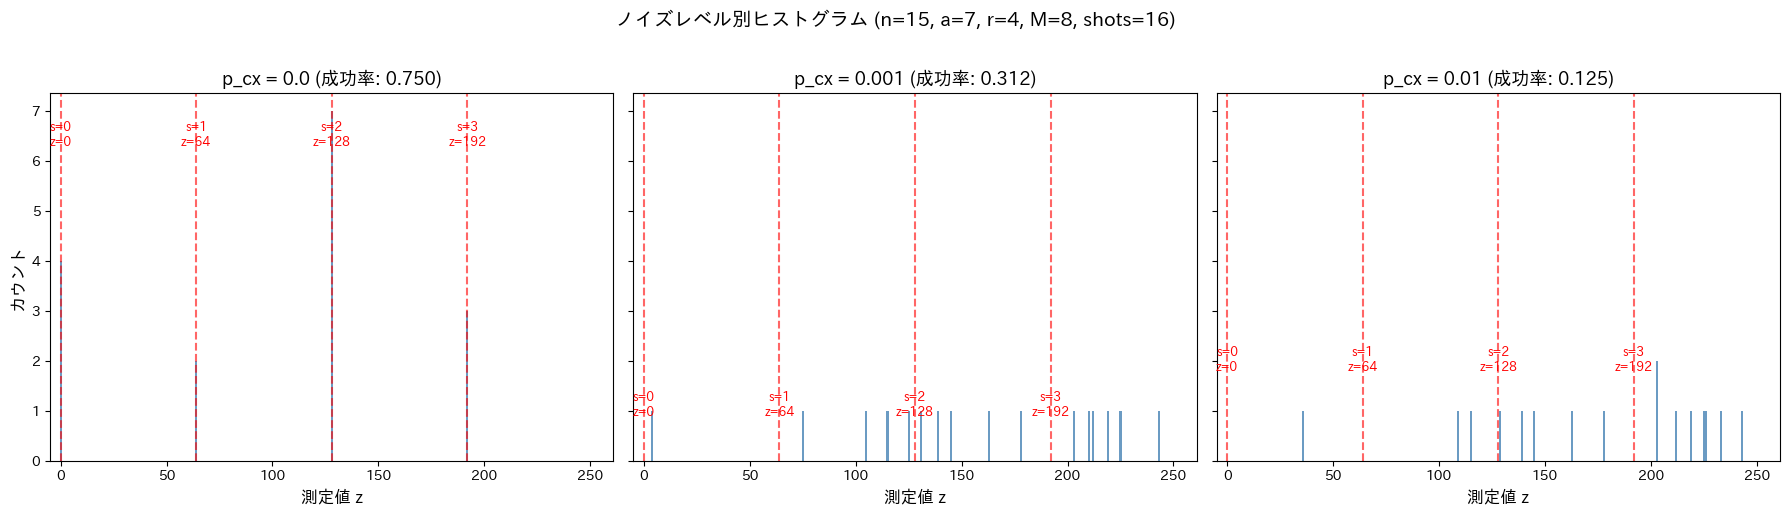

理論ピーク位置: z = s·2^M/r = [0, 64, 128, 192]
赤い破線が理論ピーク。ノイズが増えるにつれてピーク構造が崩れ、一様分布に近づいている。


In [34]:
# --- ノイズ実験 ---
# ここまで構成した回路 qc をそのまま使用する
# 「回路の実行と結果の確認」セルとの違いは AerSimulator に noise_model を渡すだけ

noise_shots = 16  # 概形確認用の軽量設定。成功率の精密比較には不十分なので、必要なら 256〜1024 に上げる

# CX ゲート数を確認 (ノイズはここに乗る)
qc_transpiled = transpile(qc, AerSimulator())
n_cx = qc_transpiled.count_ops().get('cx', 0)
print(f"=== ノイズ実験 ===")
print(f"使用する回路: n={n_number}, a={a}, M={M}")
print(f"量子ビット数: {qc.num_qubits}, CX ゲート数: {n_cx}")
print()

# --- 3つのノイズレベルで実行 ---
p_cx_values = [0.0, 0.001, 0.01]  # 比較するエラー率のリスト
noise_results = {}                         # 各エラー率の測定結果を格納する辞書

for p in p_cx_values:
    print(f"p_cx = {p:.4f} でシミュレーション中...", end=" ")
    t_start = time.time()

    if p == 0:
        # p_cx = 0: ノイズなし (理想シミュレータと同じ、比較用)
        sim = AerSimulator(method='statevector', seed_simulator=SEED)
    else:
        # p_cx > 0: ノイズモデルを作成してシミュレータに設定
        noise_model = NoiseModel()                          # 空のノイズモデルを作成
        error_cx = depolarizing_error(p, 2)                 # 2量子ビット脱分極エラーを生成
        noise_model.add_all_qubit_quantum_error(error_cx, ['cx'])  # 全 CX ゲートに適用
        sim = AerSimulator(method='statevector', noise_model=noise_model, seed_simulator=SEED)

    # 以下は理想シミュレータのときと同じ流れ
    qc_t = transpile(qc, sim, optimization_level=0)         # 回路をそのまま使用 (最適化による数値誤差を避ける)
    result = sim.run(qc_t, shots=noise_shots, seed_simulator=SEED).result()  # 実行
    counts = result.get_counts()                             # {'ビット列': 出現回数} の辞書
    noise_results[p] = counts                                # 結果を保存

    # 成功率を計算 (classify_measurement はステップ6で定義済み)
    success_count = sum(
        cnt for bs, cnt in counts.items()
        if classify_measurement(int(bs, 2), M, a, n_number)['status'] == 'success'
    )
    total = sum(counts.values())
    t_elapsed = time.time() - t_start
    print(f"成功率 = {success_count/total:.4f} [{t_elapsed:.1f}秒]")

print("\n全ノイズレベルの実行完了")





# --- ノイズレベル別ヒストグラムの比較 ---
# 横軸: 測定値 z (0〜2^M-1) 、縦軸: 出現回数
# sharey + 共通 xlim で3つのグラフを直接比較できるようにする
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# 全 z 値 (0〜2^M-1) のカウントを統一フォーマットで用意
all_zs = list(range(2**M))

for idx, (p_val, ax) in enumerate(zip(p_cx_values, axes.flat)):
    counts = noise_results[p_val]

    # ビット列を整数に変換して集計 (全 z に対して 0 埋め)
    z_counts = [0] * (2**M)
    for bitstring, count in counts.items():
        z = int(bitstring, 2)
        z_counts[z] += count

    ax.bar(all_zs, z_counts, width=1.0, color='steelblue', alpha=0.8)

    # 理論ピーク位置に赤い破線を重ねる
    max_count = max(z_counts) if max(z_counts) > 0 else 1
    for s in range(r_true):
        z_exp = round(s * 2**M / r_true)
        ax.axvline(x=z_exp, color='red', linestyle='--', alpha=0.6)
        ax.text(z_exp, max_count * 0.9, f's={s}\nz={z_exp}',
                ha='center', fontsize=9, color='red')

    # 成功率を計算してタイトルに表示
    success_count = sum(
        cnt for bs, cnt in counts.items()
        if classify_measurement(int(bs, 2), M, a, n_number)['status'] == 'success'
    )
    total = sum(counts.values())

    ax.set_title(f'p_cx = {p_val} (成功率: {success_count/total:.3f})', fontsize=13)
    ax.set_xlabel('測定値 z', fontsize=12)
    ax.set_xlim(-5, 2**M + 5)
    if idx == 0:
        ax.set_ylabel('カウント', fontsize=12)

plt.suptitle(f'ノイズレベル別ヒストグラム (n={n_number}, a={a}, r={r_true}, M={M}, shots={noise_shots})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"理論ピーク位置: z = s·2^M/r = {[round(s * 2**M / r_true) for s in range(r_true)]}")
print(f"赤い破線が理論ピーク。ノイズが増えるにつれてピーク構造が崩れ、一様分布に近づいている。")

ヒストグラムを見ると、ノイズが増えるにつれて $z = 0, 64, 128, 192$ のピーク構造が崩壊し、測定値が一様に分散していくのが分かる。

理想的な場合は $z = 0, 64, 128, 192$ のいずれかが等確率で出るため、$z=0$ 以外なら連分数展開で位数 $r=4$ が復元でき、因数分解に成功した。ノイズがあっても、たまたま正しいピーク位置の $z$ が出れば因数分解は成功する。問題は、ノイズによってピーク位置の $z$ が出る確率自体が大幅に下がることである。ピークが崩壊すると、正しい $z$ の代わりに無関係な値 (例えば $z=37$) が出やすくなり、連分数展開しても正しい位数は得られない。

では、試行回数 (shots) を増やせばピークを統計的に検出できないか。仮にピーク位置の確率がわずかでも他より高ければ、理屈としてはその通りである。しかし、本書「現状の技術での課題」節で示されている通り、CX ゲートを $N_{cx}$ 回通すと測定確率分布は理想的なピーク分布と一様分布の混合になる。

$$P(z) = (1-p_{cx})^{N_{cx}} \cdot P^{(\text{ideal})}(z) + \left(1 - (1-p_{cx})^{N_{cx}}\right) \cdot \frac{1}{2^M}$$

$(1-p_{cx})^{N_{cx}}$ がピーク信号の強度に相当する。本ハンズオンの $n=15$ 回路では $N_{cx}=128$ なので、$p_{cx}=0.005$ でも $(1-0.005)^{128} \approx 0.53$ とまだ信号は半分残る。一方、$N_{cx}$ が 5000 程度もあれば、$p_{cx}=0.005$ で $(1-0.005)^{5000} \approx 10^{-11}$ となり、正しい結果を得る確率は事実上ゼロになる。RSA-2048 規模の回路では $N_{cx}$ が $10^9$ オーダーとなるため、なおさら実行不可能である。この微小な確率差を統計的に検出するには $\sim 10^{22}$ 回の shots が必要であり、現実的な時間では実現できない。

しかも、今回のシミュレーションは CX ゲートの脱分極エラーのみをモデル化しており、実際のデバイスではこれに加えて1量子ビットゲートのエラー、デコヒーレンス (T1/T2 緩和) 、測定エラー、クロストークなど複数のノイズ源が重なる (→ 本書「現状の技術での課題」節) 。つまり、今回の結果は楽観的な見積もりであり、現実のデバイスではさらに厳しい。


つまり、誤り訂正のない NISQ デバイスでは、Shor のアルゴリズムの測定結果から位数を復元するステップ6に進むこと自体が現実的にできない。FTQC による誤り訂正なしには、Shor のアルゴリズムは実用的に機能しない。

### **コラム: FTQC 実現に向けた技術的課題**

上のノイズ実験で確認した通り、誤り訂正のない NISQ デバイスでは Shor のアルゴリズムは実用的に機能しない。Shor のアルゴリズムを動かすには、誤り訂正を備えた FTQC が必要であるが、実現は簡単ではない。

現状は論理量子ビットの数を増やしている段階だが、その上で大規模な回路を安定して実行するのはさらに難しい。FTQC の実現には、論理量子ビット数のギャップや物理量子ビットのスケールアップに加えて、回路を実行するための技術的課題も残っている。

例えば、本ハンズオンで Draper 加算器を構成した際に使った位相回転ゲート `PhaseGate(θ)` のうち、$\theta$ が $\pi/2$ の倍数でないもの (例えば $\pi/4$ や $\pi/8$) は非クリフォードゲートに分類され、代表的なものが T ゲート ($\theta = \pi/4$) である。Draper 加算器は Level 1 (モジュラー加算) → Level 2 (モジュラー乗算) → 制御モジュラー累乗と階層的に呼び出されるため、回路全体では非クリフォードゲートが大量に必要になる。しかし、誤り訂正符号 (表面符号等) のもとでこれらを直接実装することはできない。代わりに「magic state蒸留」という手順で、ノイズのある量子状態を繰り返し精製して高純度の補助状態を作り、それを消費して T ゲートを実現する。この蒸留に大量の物理量子ビットと時間を要し、FTQC のリソースの大部分を占めると見積もられている (Bravyi & Kitaev (2005) [7], Gidney & Fowler (2019) [8]) 。

また、誤り訂正ではシンドローム測定 (補助量子ビットを使ってエラーの有無を検査する操作) を繰り返し行うが、その結果を次のゲート操作までにリアルタイムで処理しフィードバックする必要がある (リアルタイムデコーディング) 。測定・古典計算・フィードバックのサイクルをゲート操作の時間スケール内に収めなければならず、制御系への要求は非常に高い (Google Quantum AI (2025) [9]) 。


こうした背景から、量子コンピュータに耐性を持つポスト量子暗号 (PQC) の標準化も進んでおり、NIST は 2024年8月に ML-KEM、ML-DSA、SLH-DSA を策定した。また、Harvest Now, Decrypt Later (暗号化された通信を今記録し、将来 FTQC で復号する) という脅威も議論されている (→ 本書「現状の技術での課題」節) 。

---

## **まとめ**



量子コンピュータが社会的にこれほど注目される柱の一つは、Shor のアルゴリズムにより RSA 暗号が破られる可能性があることである。RSA は現在のインターネットセキュリティの根幹を支えており、その安全性が崩れることの影響は計り知れない。



本ハンズオンでは、その Shor のアルゴリズムを $n=15, a=7$ の具体例で一から実装・実行し、量子コンピュータによる素因数分解の全過程を体験した。量子コンピュータで RSA 暗号がどうやって破れるのか、そして現状のデバイスではなぜまだ動かないのかが理解できれば幸いである。


| 章・ステップ | 確認したこと |
|-------------|------------|
| **1章 (古典)** | 位数 $r$ さえ分かれば $\gcd$ だけで因数分解できる。しかし素朴な古典計算では位数を求めるのに指数時間がかかり（古典最良既知法でも準指数時間で）、RSA-2048 規模では現実的に不可能 |
| **ステップ1–5 (量子)** | Beauregard のフーリエ空間算術をベースに QPE 回路を構成し、理想シミュレータで実行。測定値 $z = 0, 64, 128, 192$ の4箇所にピークが立つことを確認 |
| **ステップ6 (古典)** | 連分数展開で $z$ から位数 $r=4$ を復元し、$15 = 3 \times 5$ の因数分解に成功 |
| **成功確率** | $a$ の選択に関する古典的成功確率は $\geq 1/2$。QPE の有限精度等を含めた1試行全体の成功確率は worst-case $\Omega(1/\log \log n)$ だが、実用上は $O(1)$ 回の再試行で足りる |
| **計算量** | Shor のアルゴリズムは $O(L^3)$ で動作し、古典の準指数時間と比べて圧倒的に有利。原理的には RSA-2048 を含む任意の RSA 鍵を破れる (→ 本書「古典アルゴリズムとの比較」節)  |
| **回路規模** | RSA-2048 に必要な物理量子ビット数は、Gidney & Ekerå (2021) [1] の約 2,000 万から Gidney (2025) [12] の 100 万未満へと見積もりが改善されつつあるが、現状の実証 (96 論理量子ビット [10b]、2025年11月時点) との間には依然として大きなギャップがある (→ 本書「現状の技術での課題」節) |
| **ノイズ実験** | 少量のノイズでもピーク構造が崩壊し、正しい $z$ が得られる確率が激減する。shots を増やしても信号は回復しない。しかもこれは楽観的な見積もりであり、現実のデバイスではさらに厳しい |



量子コンピュータの話題は、ときに過度に誇張され、あたかも魔法のように語られることがある。いま何ができて、何ができないのか。センセーショナルな見出しに流されず、自分自身の手で確認し判断できるように、学び続けていきたい。

なお、ハンズオンとは別に、理論的なドキュメントがあるので、興味のある方は参照されたい。

---

## **参考文献**

> **注**: ハンズオン本文での参考文献番号は、本書PDFの番号体系とは独立です（各媒体での出現順に番号を付与しています）。同じ論文でも本書と番号が異なる場合があるため、引用を辿る際は著者名・タイトルでご参照ください。


| # | 文献 |
|---|------|
| [1] | Gidney, C. & Ekerå, M. (2021). How to factor 2048 bit RSA integers in 8 hours using 20 million noisy qubits. *Quantum*, 5, 433. [arXiv:1905.09749](https://arxiv.org/abs/1905.09749) |
| [2] | Shor, P. W. (1997). Polynomial-Time Algorithms for Prime Factorization and Discrete Logarithms on a Quantum Computer. *SIAM J. Comput.*, 26(5), 1484–1509. [arXiv:quant-ph/9508027](https://arxiv.org/abs/quant-ph/9508027) |
| [3] | Beauregard, S. (2003). Circuit for Shor's algorithm using 2n+3 qubits. *Quantum Information & Computation*, 3(2), 175–185. [arXiv:quant-ph/0205095](https://arxiv.org/abs/quant-ph/0205095) |
| [4] | Draper, T. G. (2000). Addition on a Quantum Computer. [arXiv:quant-ph/0008033](https://arxiv.org/abs/quant-ph/0008033) |
| [5] | Nielsen, M. A. & Chuang, I. L. (2010). *Quantum Computation and Quantum Information*. 10th Anniversary Edition. Cambridge University Press. |
| [6] | Kjaergaard, M. et al. (2020). Superconducting Qubits: Current State of Play. *Annual Review of Condensed Matter Physics*, 11, 369–395. |
| [7] | Bravyi, S. & Kitaev, A. (2005). Universal quantum computation with ideal Clifford gates and noisy ancillas. *Phys. Rev. A*, 71, 022316. [arXiv:quant-ph/0403025](https://arxiv.org/abs/quant-ph/0403025) |
| [8] | Gidney, C. & Fowler, A. G. (2019). Efficient magic state factories with a catalyzed $|CCZ\rangle$ to $2|T\rangle$ transformation. *Quantum*, 3, 135. [arXiv:1812.01238](https://arxiv.org/abs/1812.01238) |
| [9] | Google Quantum AI (2025). Quantum error correction below the surface code threshold. *Nature*, 638, 920–926 (online 2024-12-09). |
| [10] | Bluvstein, D. et al. (2024). Logical quantum processor based on reconfigurable atom arrays. *Nature*, 626, 58–65. |
| [10b] | Bluvstein, D. et al. (2026). A fault-tolerant neutral-atom architecture for universal quantum computation. *Nature*, 649, 39–46 (published online 2025-11-10). [doi:10.1038/s41586-025-09848-5](https://doi.org/10.1038/s41586-025-09848-5) (距離 $d=4$ で最大96論理qubitの実証。[10]の後続研究) |
| [11] | Ragavan, S. & Vaikuntanathan, V. (2024). Space-Efficient and Noise-Robust Quantum Factoring. *CRYPTO 2024*. [arXiv:2310.00899](https://arxiv.org/abs/2310.00899) |
| [12] | Gidney, C. (2025). How to factor 2048 bit RSA integers with less than a million noisy qubits. [arXiv:2505.15917](https://arxiv.org/abs/2505.15917) |

※ 量子コンピュータのハードウェア性能や資源見積もりは急速に更新されている。本ハンズオンの数値は執筆時点のものであり、最新の状況は各文献や関連機関の発表を参照されたい。